# Импорты

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.signal as sg
import math
import sounddevice as sd
import soundfile as sf
import scipy as sp

# Помогаторы

In [2]:
def plotSTFT(
    signal, 
    Fs, 
    nperseg,
    noverlap,
    *,
    nfft = None, 
    window = 'boxcar',  # 'boxcar', 'hann', 'hamming', 'blackman', 'bartlett', 'flattop', 'parzen', 'bohman', 'blackmanharris', 'nuttall', 'barthann'
    Fmax = None, 
    F_lim = None,
    use_log_scale = False, 
    figsize = (16, 6), 
    cmap = 'viridis'
) -> None:

    f, t, spectrum = sg.stft(
        signal, 
        fs=Fs, 
        window=window, 
        nperseg=nperseg, 
        noverlap=noverlap, 
        nfft=nfft, 
        return_onesided=False, 
        boundary=None, 
        padded=False
    )
    actual_nfft = nfft if nfft is not None else nperseg
    
    spectrum *= spectrum.shape[1] / nperseg
    
    f = np.fft.fftshift(f)
    spectrum = np.fft.fftshift(spectrum, axes=0)
    
    amplitude = np.abs(spectrum)
    
    plt.figure(figsize=figsize)

    if use_log_scale:
        display_data = 20 * np.log10(amplitude + 1e-12) 
        plt.ylabel("Frequency, Hz")
        plt.title("STFT Magnitude (dB)")
    else:
        display_data = amplitude
        plt.ylabel("Frequency, Hz")
        plt.title("STFT Magnitude")

    if len(t) == 1:
        dt = 1 / Fs
        df = Fs / actual_nfft
        
        R = nperseg - noverlap
        t_half_width = (R * dt) / 2
        
        t_edges = np.array([t[0] - t_half_width, t[0] + t_half_width])
        f_edges = np.append(f - df/2, f[-1] + df/2)
        
        plt.pcolormesh(t_edges, f_edges, display_data, shading='flat', cmap=cmap)
    else:   
        plt.pcolormesh(t, f, display_data, shading='nearest', cmap=cmap)
        
    plt.xlabel("Time, s")
    plt.colorbar(label='Amplitude' if not use_log_scale else 'dB')
    plt.rc("font", size=15)

    if F_lim:
        plt.ylim(F_lim)
    elif Fmax:
        plt.ylim((-Fmax, Fmax)) 
    else:
        plt.ylim((-Fs / 2, Fs / 2))

    plt.tight_layout()
    plt.show()

In [3]:
def plotSignalTime(signal, Fs, Tmax = None, label = None, linestyle=None, color=None, figsize=(16, 3), usegrid=True, y_lim=None, x_lim=None):
   
    dt = 1 / Fs
    t = np.linspace(0, len(signal)*dt, len(signal), endpoint=False)
    plt.plot(t, signal, label=label, linestyle=linestyle, color=color)
    
    # Add empty borders
    if (Tmax):
        plt.xlim((0, Tmax))
    elif x_lim:
        plt.xlim(x_lim)
        
    if y_lim:
        plt.ylim(y_lim)
        
    #plt.stem(signal)
    plt.ylabel('Amplitude')
    plt.xlabel('time, s')
    plt.rc('font', size=15)
    
    if usegrid:
        plt.grid()
    
    if label:
        plt.legend()
        
    fig = plt.gcf()
    fig.set_size_inches(figsize)

In [4]:
def plotAmplFreqResp(signal, Fs, Fmax = None, label = None, use_log_scale = False, use_grid = True, DFT_size = None, y_lim=None, f_lim=None, figsize=(16, 3)):   
    
    fft_signal = np.fft.fft(signal, n=DFT_size) # make FFT of info signal
    fft_signal = np.fft.fftshift(fft_signal) # shift FFT so that DC (zero frequency) is at center
    N = len(fft_signal)
    freqs = np.fft.fftfreq(N, d=1/Fs)
    freqs = np.fft.fftshift(freqs)
    
    if use_log_scale:
        plt.plot(freqs, 10*np.log10(np.abs(fft_signal) + 1e-10), label=label)
        plt.ylabel('Amplitude, dB')
    else:
        plt.plot(freqs, np.abs(fft_signal), label=label)
        plt.ylabel('Amplitude')
    plt.xlabel('Frequency, Hz')
    plt.rc('font', size=15)
    
    # Add empty borders
    if (Fmax):
        plt.xlim((-Fmax, Fmax))
    elif (f_lim):
        plt.xlim(f_lim)
    else:
        plt.xlim((-Fs / 2, Fs / 2))
        
    if (y_lim):
        plt.ylim(y_lim)
        
    if use_grid:
        plt.grid(visible=1, which='both')
        plt.minorticks_on()
        plt.grid(which='major',
                linewidth = 2)
        plt.grid(which='minor', 
                linestyle = ':')
    if label:
        plt.legend()
            
    fig = plt.gcf()
    fig.set_size_inches(figsize[0], figsize[1])


In [5]:
def periodic_corr_np(x, y):
    """
    x and y must be real sequences with the same length.
    """
    return np.correlate(x, np.hstack((y[1:], y)), mode='valid')

In [6]:
def corr_np(x, y):
    return np.correlate(x, y, mode='full')

In [7]:
data, fs = sf.read('input.wav')

In [10]:
fs

48000

In [15]:
t_arr= np.arange(len(data)) / fs

In [16]:
idx1 = np.searchsorted(t_arr, 6.0)
idx2 = np.searchsorted(t_arr, 9.0)

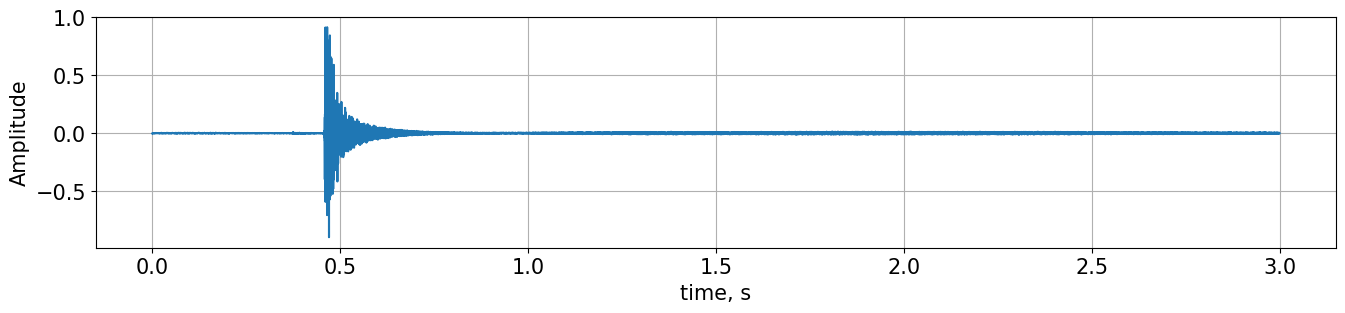

In [19]:
plotSignalTime(data[idx1:idx2], fs)


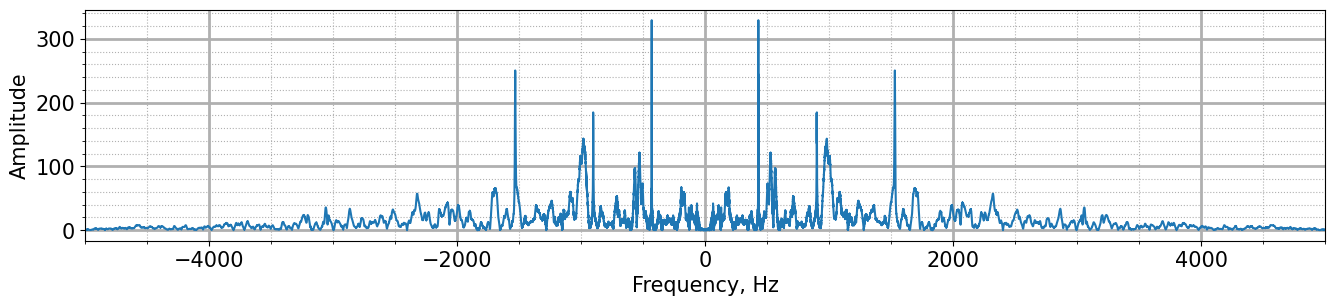

In [61]:
plotAmplFreqResp(data[idx1:idx2], fs, use_log_scale=False, Fmax=5000, DFT_size=1000000)

array([ 0.15231323+0.j        ,  0.13495448-0.08412584j,
        0.07958866-0.15883832j, ..., -0.01533387+0.20349056j,
        0.07958866+0.15883832j,  0.13495448+0.08412584j], shape=(1000000,))

In [48]:
sp.signal.find_peaks(np.abs(np.fft.fft(data[idx1:idx2], n=1000000)), height=300)

(array([  8960,   8968, 991032, 991040]),
 {'peak_heights': array([329.2371785 , 313.19978253, 313.19978253, 329.2371785 ])})

In [62]:
np.fft.fftfreq(1000000, d=1/fs)[8968]

np.float64(430.464)

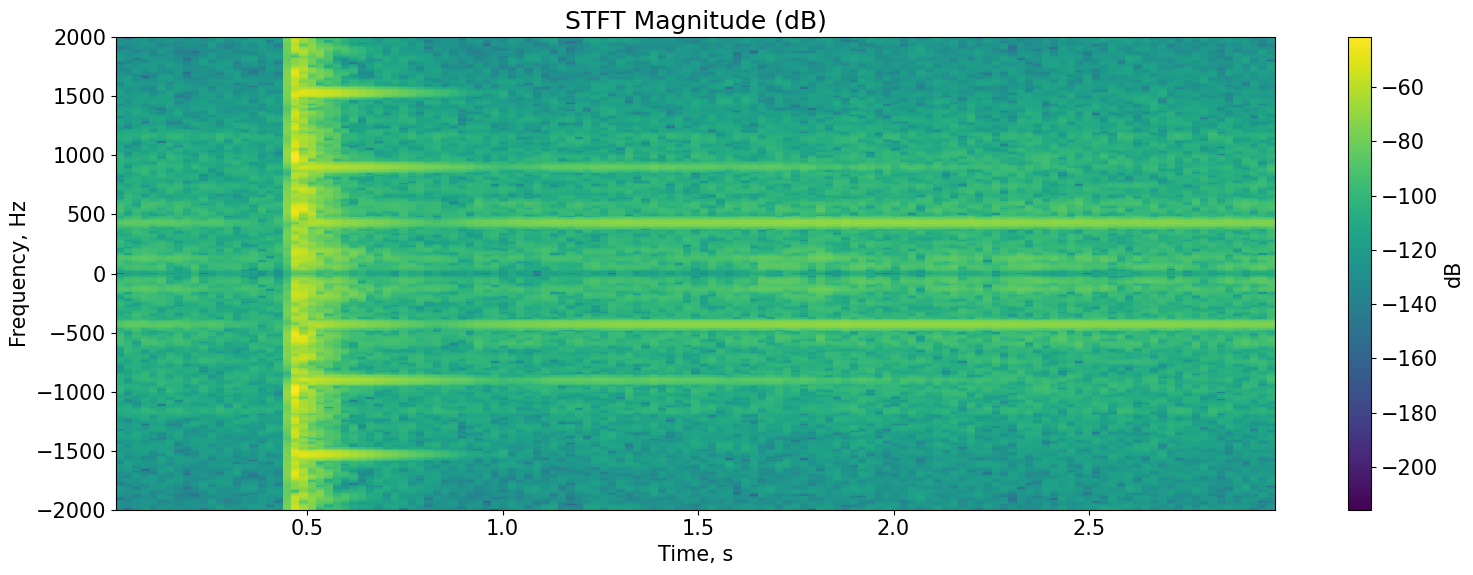

In [33]:
plotSTFT(data[idx1:idx2], fs, nperseg=2048, noverlap=1024, nfft=4096, Fmax=2000, use_log_scale=True, window='blackman')

# Синхросигналы

## Случайная последовательность

Periodic autocorrelation


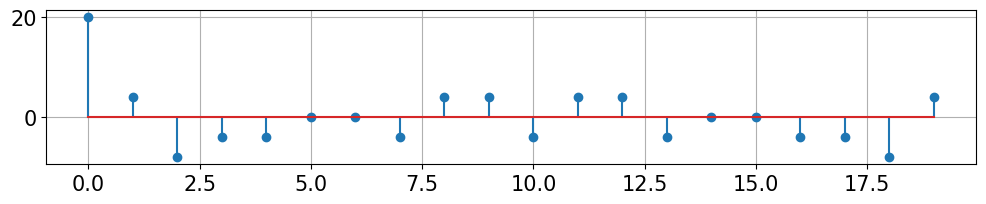

Linear autocorrelation


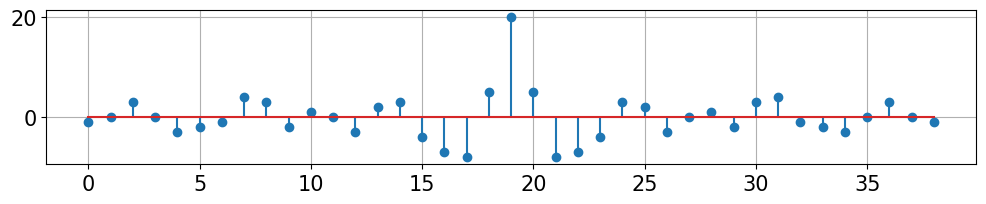

In [2667]:
sequence = np.random.choice([-1, 1], 20)

# Periodic autocorrelation #
print("Periodic autocorrelation")
plt.figure(figsize=(12, 2))
plt.stem(periodic_corr_np(sequence, sequence))
plt.grid(visible=True, which='major', axis='both')
plt.show()

# Linear autocorrelation #
plt.figure(figsize=(12, 2))
print("Linear autocorrelation")
plt.stem(corr_np(sequence, sequence))
plt.grid(visible=True, which='major', axis='both')

## M-sequence (max length sequence)

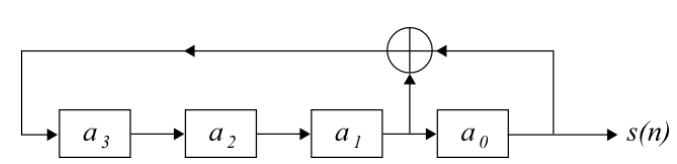

Почти как на картинке, только для 3-х ячеек регистра + не удаляем вытесненные элементы


In [2668]:
m_sequence = np.array([1,0,0,0,0,0])
m = len(m_sequence)
N = 2**m-1

for i in range(N-m):
    m_sequence = np.append(m_sequence, m_sequence[i] ^ m_sequence[i+1])

In [2669]:
m_sequence = m_sequence*2-1

In [2670]:
m_sequence

array([ 1, -1, -1, -1, -1, -1,  1, -1, -1, -1, -1,  1,  1, -1, -1, -1,  1,
       -1,  1, -1, -1,  1,  1,  1,  1, -1,  1, -1, -1, -1,  1,  1,  1, -1,
       -1,  1, -1, -1,  1, -1,  1,  1, -1,  1,  1,  1, -1,  1,  1, -1, -1,
        1,  1, -1,  1, -1,  1, -1,  1,  1,  1,  1,  1])

Periodic autocorrelation


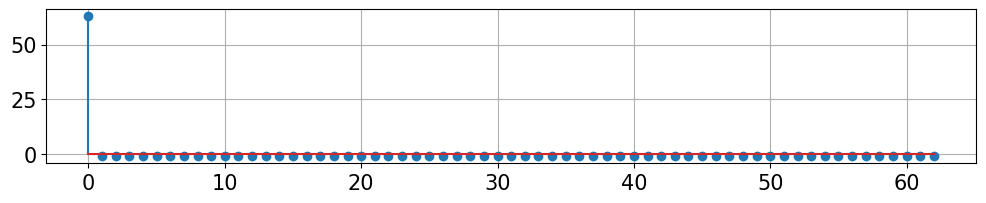

Linear autocorrelation


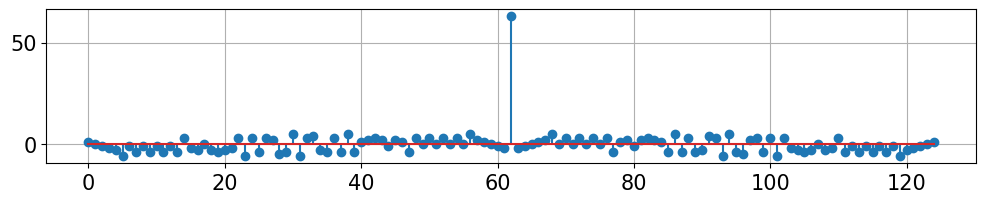

In [2671]:
# Periodic autocorrelation #
print("Periodic autocorrelation")
plt.figure(figsize=(12, 2))
plt.stem(periodic_corr_np(m_sequence, m_sequence))
plt.grid(visible=True, which='major', axis='both')
plt.show()

# Linear autocorrelation #
plt.figure(figsize=(12, 2))
print("Linear autocorrelation")
plt.stem(corr_np(m_sequence, m_sequence))
plt.grid(visible=True, which='major', axis='both')

## Barker code

In [2672]:
barker_sequences = {
    2:  np.array([1, -1]),
    3:  np.array([1, 1, -1]),
    4:  np.array([1, 1, -1, 1]),
    5:  np.array([1, 1, 1, -1, 1]),
    7:  np.array([1, 1, 1, -1, -1, 1, -1]),
    11: np.array([1, 1, 1, -1, -1, -1, 1, -1, -1, 1, -1]),
    13: np.array([1, 1, 1, 1, 1, -1, -1, 1, 1, -1, 1, -1, 1])
}

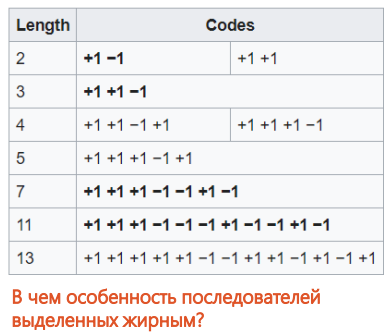
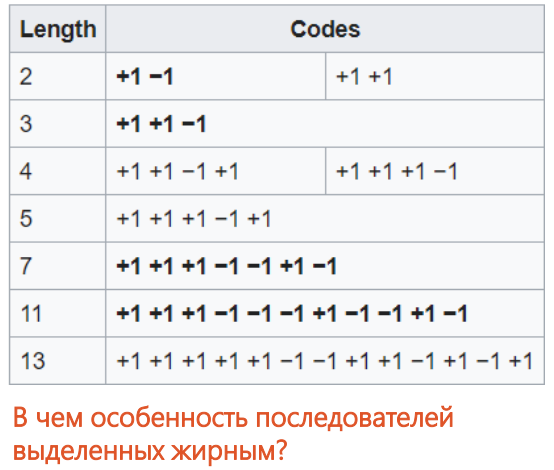
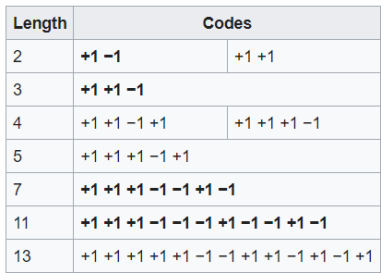

Periodic autocorrelation


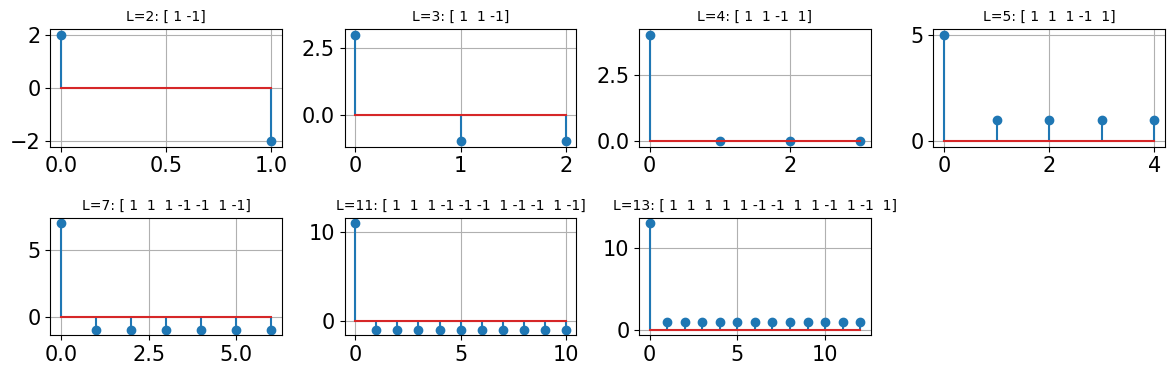

Linear autocorrelation


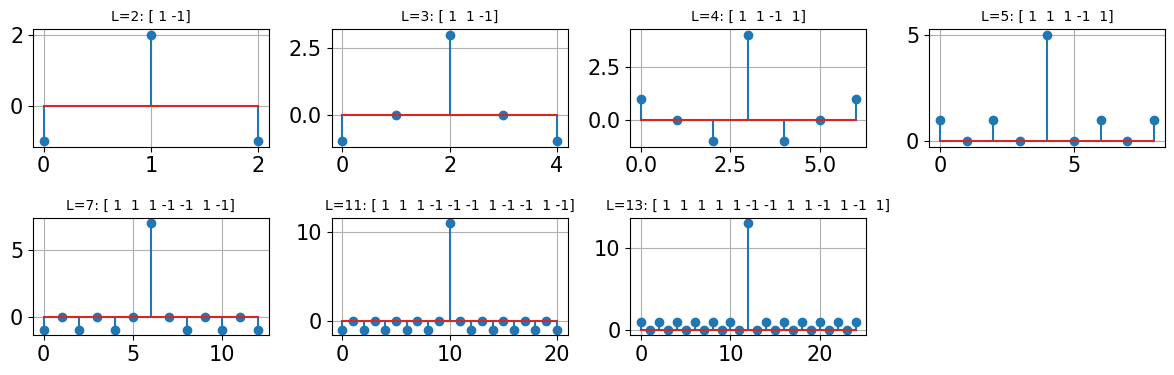

In [2673]:
# Periodic autocorrelation #
cols = 4
rows = math.ceil(len(barker_sequences) / cols)
plt.figure(figsize=(12, 2 * rows))

print("Periodic autocorrelation")

for i, (L, seq) in enumerate(barker_sequences.items(), 1):
    plt.subplot(rows, cols, i)
    plt.stem(periodic_corr_np(seq, seq))
    plt.title(f'L={L}: {seq}', fontsize=10)
    plt.grid()
    
plt.tight_layout()
plt.show()

# Linear autocorrelation #
plt.figure(figsize=(12, 2 * rows))

print("Linear autocorrelation")

for i, (L, seq) in enumerate(barker_sequences.items(), 1):
    plt.subplot(rows, cols, i)
    plt.stem(corr_np(seq, seq))
    plt.title(f'L={L}: {seq}', fontsize=10)
    plt.grid()
    
plt.tight_layout()
plt.show()

Особенность последовательностей, выделенных жирным - их боковые лепестки <= 0?

Тут сложно сказать, какой из типов корреляции лучше


# Sound recording and playing example

In [2674]:
fs = 44100
duration = 1 #s
frequency = 800 #Hz

t = np.linspace(0, duration, int(fs * duration))
data = 0.5 * np.cos(2 * np.pi * frequency * t)

In [2675]:
# Play the sound
sd.play(data, fs)

In [2676]:
# Record audio data from your sound device
duration = 2 # seconds
myrecording = sd.rec(int(duration * fs), samplerate=fs, channels=1)
sd.wait()

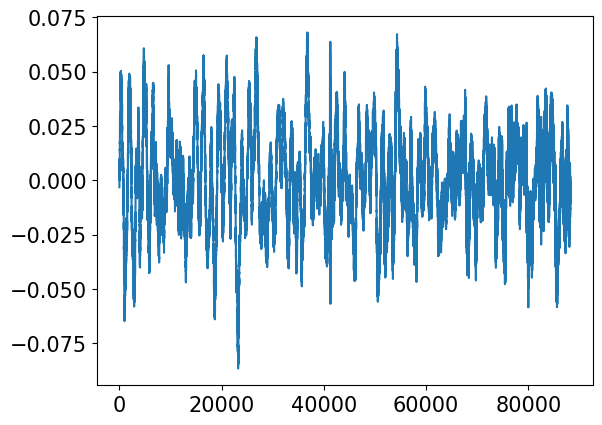

In [2677]:
plt.plot(myrecording)

In [2678]:
sd.play(myrecording, fs)

# Homework

## 1. Переводим текст в битовую строку

In [2679]:
def string_to_bits(text):
    return ''.join(f"{char:08b}" for char in text.encode('utf-8'))

In [4148]:
message_str = "Привет! Как дела?"
message_bits = string_to_bits(message_str)
message_bits_arr = np.array(list(map(int, message_bits)))
display(message_bits)
display(message_bits_arr)

'110100001001111111010001100000001101000010111000110100001011001011010000101101011101000110000010001000010010000011010000100110101101000010110000110100001011101000100000110100001011010011010000101101011101000010111011110100001011000000111111'

array([1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 0,
       0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 1, 1,
       1, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 1,
       0, 1, 0, 0, 0, 0, 1, 0, 1, 1, 0, 1, 0, 1, 1, 1, 0, 1, 0, 0, 0, 1,
       1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0,
       0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 1, 0, 1, 1, 0, 1,
       0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0,
       1, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0,
       1, 0, 1, 1, 0, 1, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 1, 1, 0, 1,
       0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1,
       0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1])

## 2. Используем последовательность Баркера длиной 11

array([ 1,  1,  1, -1, -1,  1, -1])

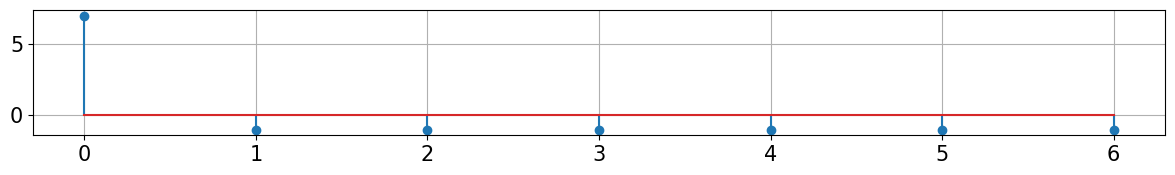

In [4149]:
bit_sync_sequence_symbols = barker_sequences[7]
display(bit_sync_sequence_symbols)
corr_result = periodic_corr_np(bit_sync_sequence_symbols, bit_sync_sequence_symbols)

plt.figure(figsize=(12, 2))
plt.stem(corr_result)
plt.tight_layout()
plt.grid()

# Чуть позже добавим в последовательность дополнительные отсчеты

### Допом сделаем тренировочную последовательность для синхронизации частоты

endpoint=False обязателен!!! Иначе частота едет

Удобно делать длительность этой последовательности кратной длительность символа

symbol_duration: 22.675736961451246 ms
max_samples: 132300
train_seq_duration_aim: 0.45351473922902497 s
real freq: 44100.0
train_seq_duration_real: 0.4534920634920635 s


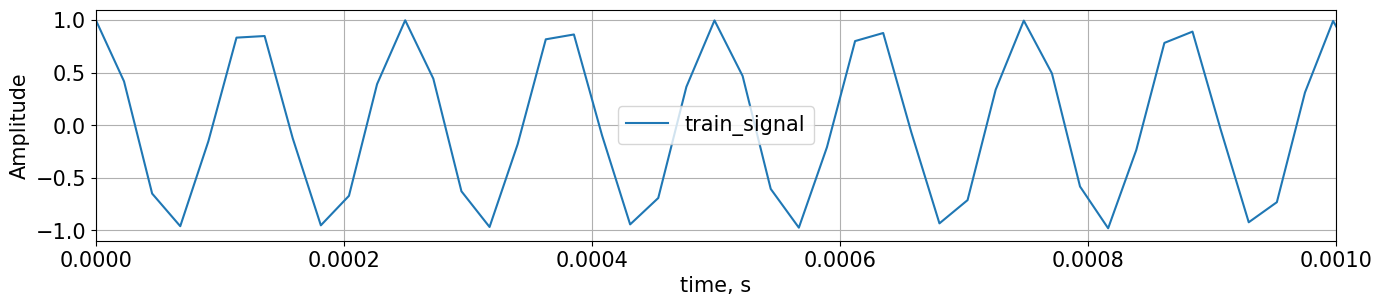

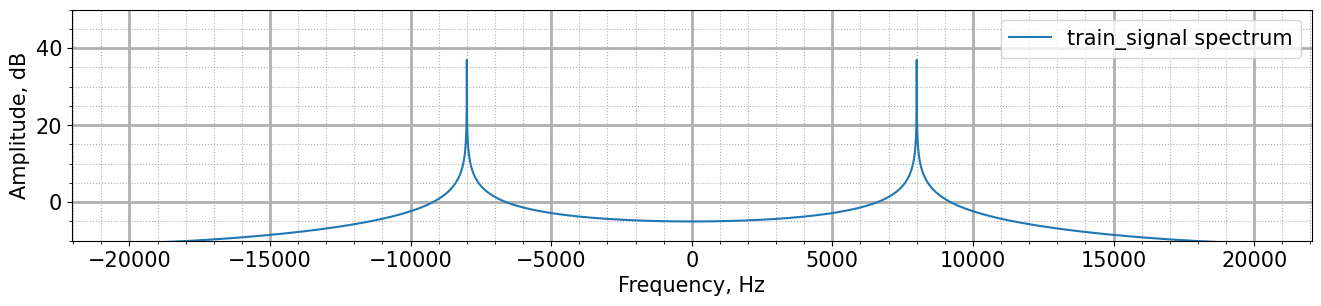

In [4152]:
Fs = 44100   # Hz
dt = 1 / Fs  # seconds

samples_per_symbol = 1000  # samples
symbol_duration = samples_per_symbol * dt  # seconds
print(f"symbol_duration: {symbol_duration * 10**3} ms")

max_duration = 3  # seconds
max_samples = int(Fs * max_duration)
print(f"max_samples: {max_samples}")

train_seq_duration_symbols = 20
train_seq_duration_aim = train_seq_duration_symbols*symbol_duration    # sec
print(f"train_seq_duration_aim: {train_seq_duration_aim} s")
t_train_seq_arr = np.linspace(0, train_seq_duration_aim, int(Fs * train_seq_duration_aim), endpoint=False)
train_seq_duration_real = t_train_seq_arr[-1]
print(f'real freq: {1/np.diff(t_train_seq_arr)[0]}')
print(f"train_seq_duration_real: {train_seq_duration_real} s")

Fc = 8000  # carrier frequency in Hz
train_signal = np.cos(2 * np.pi * Fc * t_train_seq_arr)

plotSignalTime(train_signal, Fs, Tmax=0.001, label='train_signal')
plt.show()
plotAmplFreqResp(train_signal, Fs, label='train_signal spectrum', use_log_scale=True, y_lim=(-10, 50), DFT_size=10000)

## 3. Делаем baseband signal

Код из предыдущей лабы

In [4153]:
def make_wide(data_symbols, samples_per_symbol, scale_multiplier):
    return np.kron(data_symbols, np.tile(scale_multiplier, samples_per_symbol))

def undo_make_wide(wide_data, samples_per_symbol, scale_multiplier):
    reshaped = wide_data.reshape(-1, samples_per_symbol)
    return reshaped[:, 0] / scale_multiplier

In [4154]:
bits_per_symbol = 2
alphabet_size = 2**bits_per_symbol

data_size_bits = len(message_bits)
assert data_size_bits % bits_per_symbol == 0  # По идее должно всегда срабатывать
data_size_symbols = data_size_bits // bits_per_symbol
print(f"data_size_bits: {data_size_bits}")
print(f"data_size_symbols: {data_size_symbols}")

data_size_bits: 240
data_size_symbols: 120


Переводим биты в символы

In [4155]:
message_bits_arr_reshaped = message_bits_arr.reshape(-1, bits_per_symbol)
print(f"Первые несколько символов: \n{message_bits_arr_reshaped[:5]}")

powers = 2 ** np.arange(bits_per_symbol)[::-1]
print(f"powers: {powers}")
data_symbols = message_bits_arr_reshaped.dot(powers)

print(f'data_symbols: {data_symbols}') 

Первые несколько символов: 
[[1 1]
 [0 1]
 [0 0]
 [0 0]
 [1 0]]
powers: [2 1]
data_symbols: [3 1 0 0 2 1 3 3 3 1 0 1 2 0 0 0 3 1 0 0 2 3 2 0 3 1 0 0 2 3 0 2 3 1 0 0 2
 3 1 1 3 1 0 1 2 0 0 2 0 2 0 1 0 2 0 0 3 1 0 0 2 1 2 2 3 1 0 0 2 3 0 0 3 1
 0 0 2 3 2 2 0 2 0 0 3 1 0 0 2 3 1 0 3 1 0 0 2 3 1 1 3 1 0 0 2 3 2 3 3 1 0
 0 2 3 0 0 0 3 3 3]


In [4156]:
norm_factor = np.sqrt((alphabet_size-1) * (alphabet_size+1) / 3)  # Нормируем так, чтобы мощность была единичной (мощность = среднее квадратов символов)
print(f"norm_factor={norm_factor}")

scale_multiplier = 2
baseband_signal = make_wide(data_symbols, samples_per_symbol=samples_per_symbol, scale_multiplier=scale_multiplier)
baseband_signal = baseband_signal - (alphabet_size - 1)  # DC removal
print(f"baseband_signal={baseband_signal}")
print(f"Форма: {baseband_signal.reshape(-1, samples_per_symbol).shape}")
normalized_baseband_signal = baseband_signal / norm_factor  # Normalization 

t_arr = np.linspace(0, len(normalized_baseband_signal)*dt, len(normalized_baseband_signal), endpoint=False)

print(f'Длительность полезного сигнала: {t_arr[-1]} s')

norm_factor=2.23606797749979
baseband_signal=[3 3 3 ... 3 3 3]
Форма: (120, 1000)
Длительность полезного сигнала: 2.721065759637188 s


In [4157]:
def plot_symbols(normalized_baseband_signal, symbols_to_plot, samples_per_symbol, Fs, label=None, linestyle=None, color=None, figsize=(16, 3), y_lim=None):
    dt = 1 / Fs
    Tmax = symbols_to_plot*samples_per_symbol*dt
    plotSignalTime(normalized_baseband_signal, Fs, Tmax, label=label, linestyle=linestyle, color=color, figsize=figsize, usegrid=False, y_lim=y_lim)
    plt.xticks(np.arange(0, Tmax, samples_per_symbol*dt), rotation=45, fontsize=8)
    plt.grid(True, axis='x')

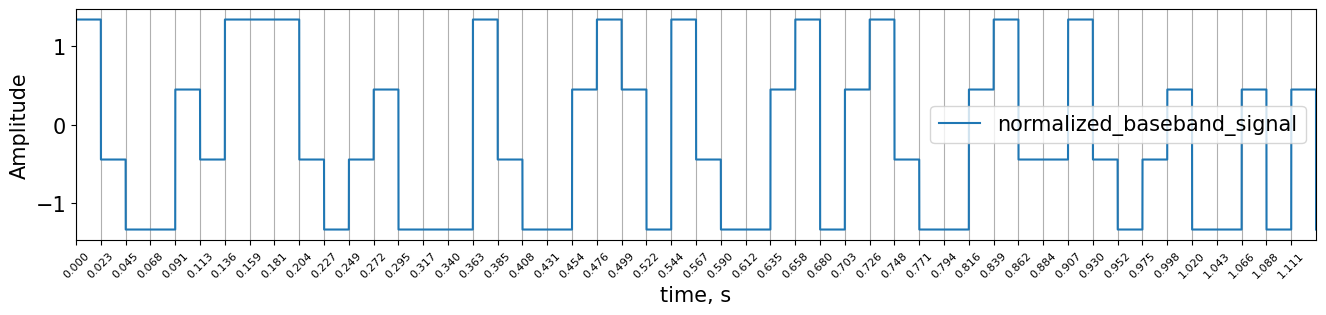

In [4158]:
symbols_to_plot_raw = 50

plot_symbols(normalized_baseband_signal, symbols_to_plot_raw, samples_per_symbol, Fs, label='normalized_baseband_signal')

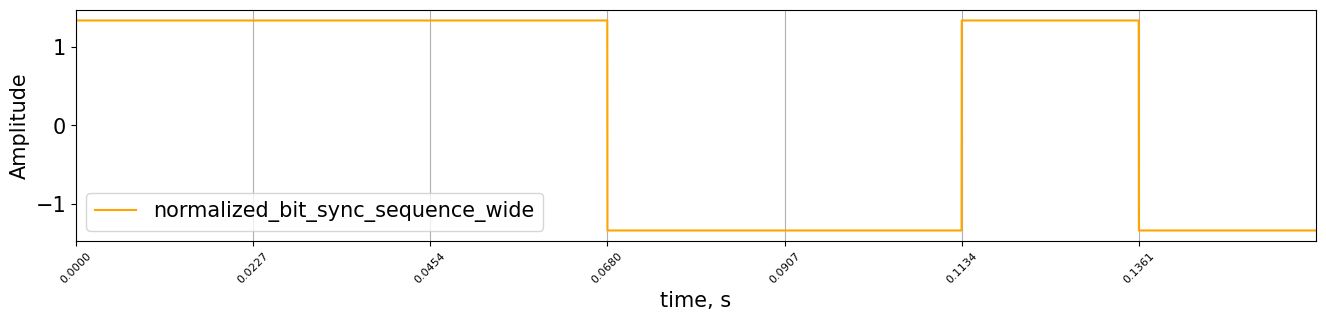

In [4159]:
normalized_bit_sync_sequence_wide = make_wide(bit_sync_sequence_symbols, samples_per_symbol, alphabet_size - 1) / norm_factor  # Дополнительно масштабируем до максимальной амплитуды для различимости

plot_symbols(normalized_bit_sync_sequence_wide, len(bit_sync_sequence_symbols), samples_per_symbol, Fs, label='normalized_bit_sync_sequence_wide', color='orange')


Periodic autocorrelation


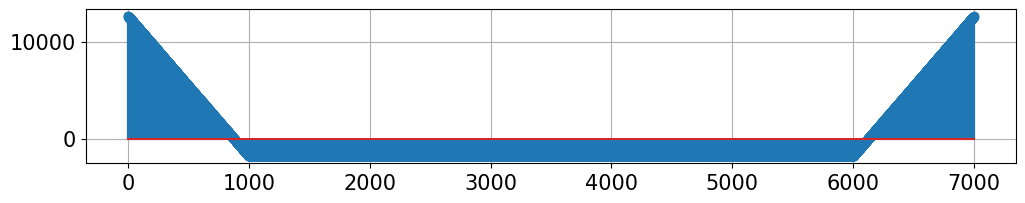

Linear autocorrelation


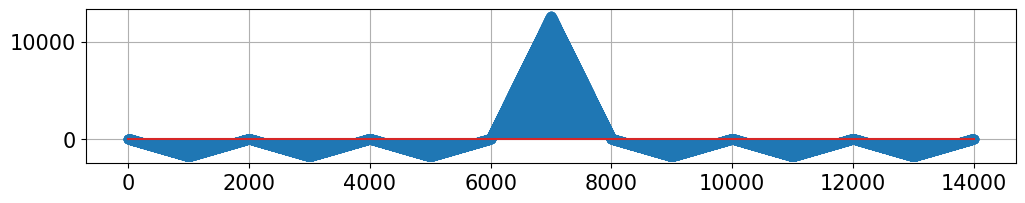

In [4160]:
# Periodic autocorrelation #
print("Periodic autocorrelation")
plt.figure(figsize=(12, 2))
plt.stem(periodic_corr_np(normalized_bit_sync_sequence_wide, normalized_bit_sync_sequence_wide))
plt.grid(visible=True, which='major', axis='both')
plt.show()

# Linear autocorrelation #
plt.figure(figsize=(12, 2))
print("Linear autocorrelation")
plt.stem(corr_np(normalized_bit_sync_sequence_wide, normalized_bit_sync_sequence_wide))
plt.grid(visible=True, which='major', axis='both')

Тренировочную последовательность добавим после модуляции

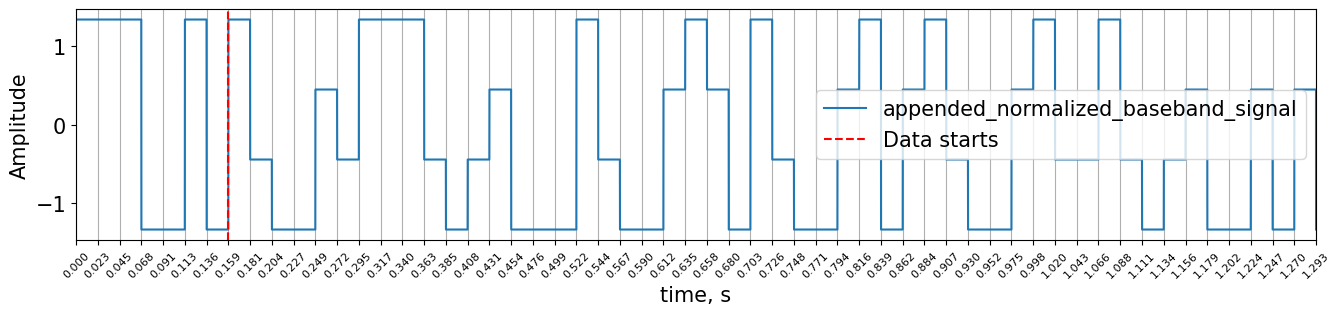

In [4161]:
symbols_to_plot=len(bit_sync_sequence_symbols) + symbols_to_plot_raw

# data_to_transmit_raw = np.concatenate((train_signal * (alphabet_size - 1) / norm_factor, bit_sync_sequence_wide, normalized_baseband_signal))
appended_normalized_baseband_signal = np.concatenate((normalized_bit_sync_sequence_wide, normalized_baseband_signal))
t_raw_arr = np.linspace(0, len(appended_normalized_baseband_signal)*dt, len(appended_normalized_baseband_signal), endpoint=False)

plot_symbols(appended_normalized_baseband_signal, symbols_to_plot, samples_per_symbol, Fs, label='appended_normalized_baseband_signal')
plt.axvline(x=len(bit_sync_sequence_symbols)*samples_per_symbol*dt, color='red', linestyle='--', label='Data starts')
plt.legend()
plt.show()

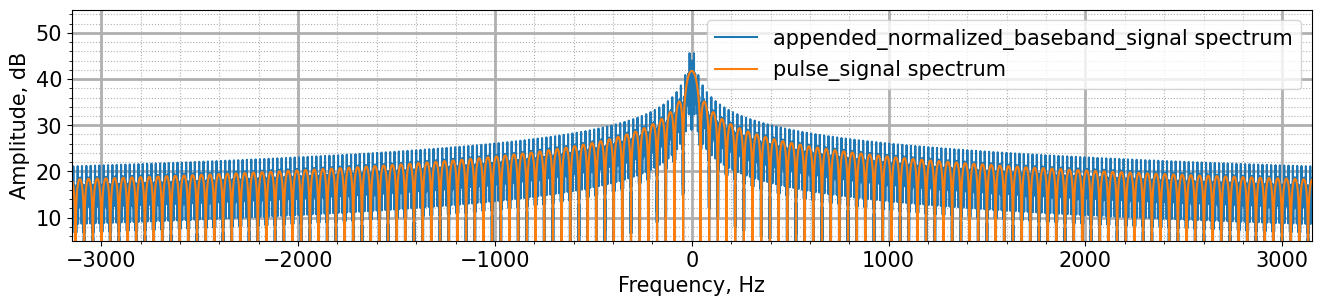

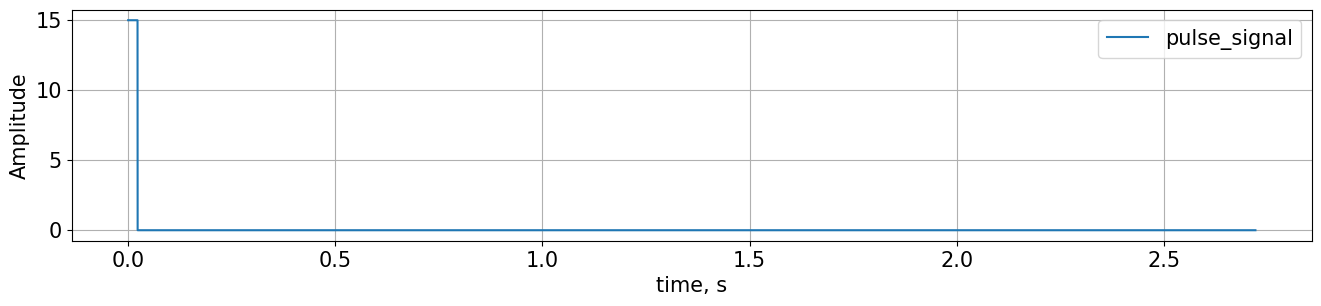

In [4162]:
use_log = True
Fmax = Fs / 2 / 7

# plotAmplFreqResp(data_to_transmit_raw, Fs, Fmax, use_log_scale=use_log, label='data_to_transmit_raw spectrum')
plotAmplFreqResp(appended_normalized_baseband_signal, Fs, Fmax, use_log_scale=use_log, label='appended_normalized_baseband_signal spectrum')

pulse_signal = np.tile(0, data_size_symbols*samples_per_symbol)
pulse_signal[0:samples_per_symbol] = np.sqrt(data_size_bits)
plotAmplFreqResp(pulse_signal, Fs, Fmax, use_log_scale=use_log, label='pulse_signal spectrum')

if use_log:
    plt.ylim((5,55))
    
plt.show()

plotSignalTime(pulse_signal, Fs, label='pulse_signal')

## 4. Модулируем с CPFSK

### Premodulation filter

In [4180]:
should_filter = True

baud_rate = 1 / symbol_duration  # Еще это совпадает с bw (bandwidth)
cutoff_freq = baud_rate * 20

# в формате second-order sections (sos) для численной стабильности
sos_bessel = sg.iirfilter(N=4, Wn=cutoff_freq, btype='low', fs=Fs, output='sos')

# Применяем фильтр к data_to_transmit_raw двунаправленно, чтобы избежать задержки
premod_filtered_signal = sg.sosfiltfilt(sos_bessel, appended_normalized_baseband_signal) if should_filter else appended_normalized_baseband_signal

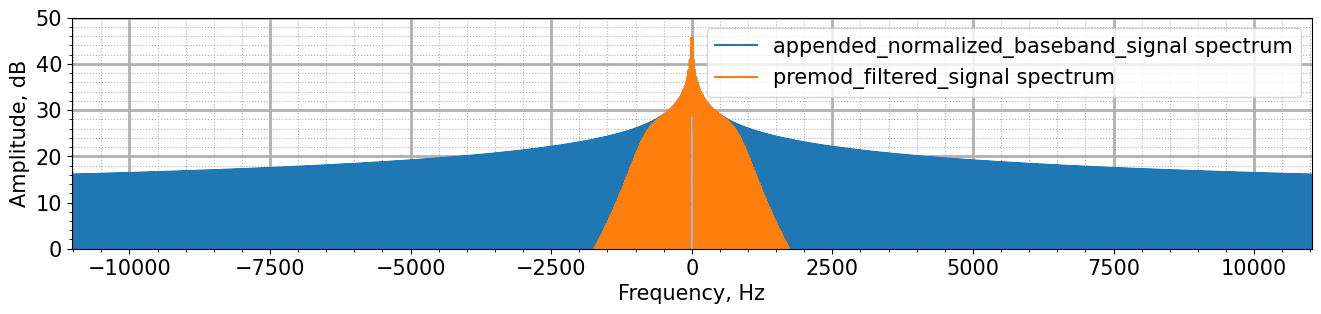

In [4181]:
Fmax = Fs / 2 / 2
use_log = True

plotAmplFreqResp(appended_normalized_baseband_signal, Fs, Fmax, use_log_scale=use_log, label='appended_normalized_baseband_signal spectrum')
plotAmplFreqResp(premod_filtered_signal, Fs, Fmax, use_log_scale=use_log, label='premod_filtered_signal spectrum')

if use_log:
    plt.ylim((0, 50))


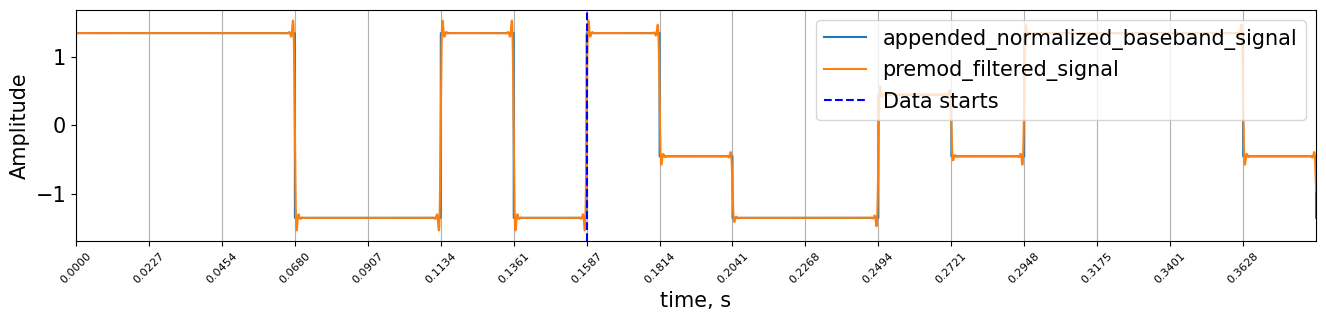

In [4182]:
symbols_to_plot=len(bit_sync_sequence_symbols) + symbols_to_plot_raw

plot_symbols(appended_normalized_baseband_signal, symbols_to_plot, samples_per_symbol, Fs, label='appended_normalized_baseband_signal')
plot_symbols(premod_filtered_signal, symbols_to_plot, samples_per_symbol, Fs, label='premod_filtered_signal')

plt.axvline(x=len(bit_sync_sequence_symbols)*samples_per_symbol*dt, color='blue', linestyle='--', label='Data starts')
plt.legend(loc='upper right')
plt.show()

### Сама модуляция

FSK: $s(t) = \cos(2\pi (f_c + f_d \cdot s_m(t))t)$           

CPFSK $s(t) = \cos(2\pi f_c t + 2 \pi f_d \int s_m(t) dt)$  

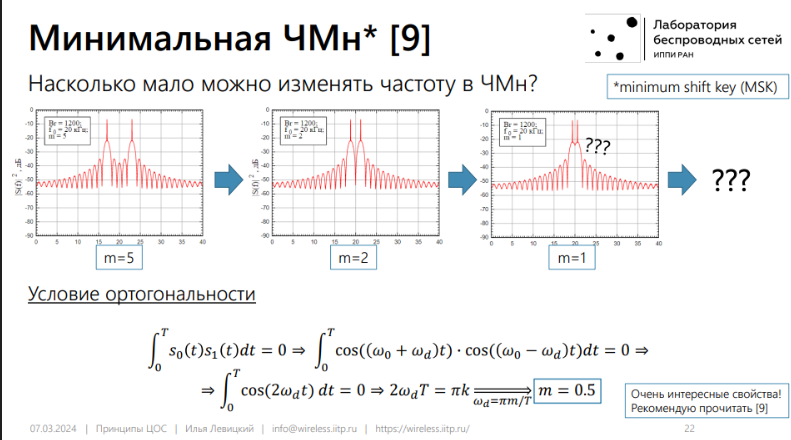
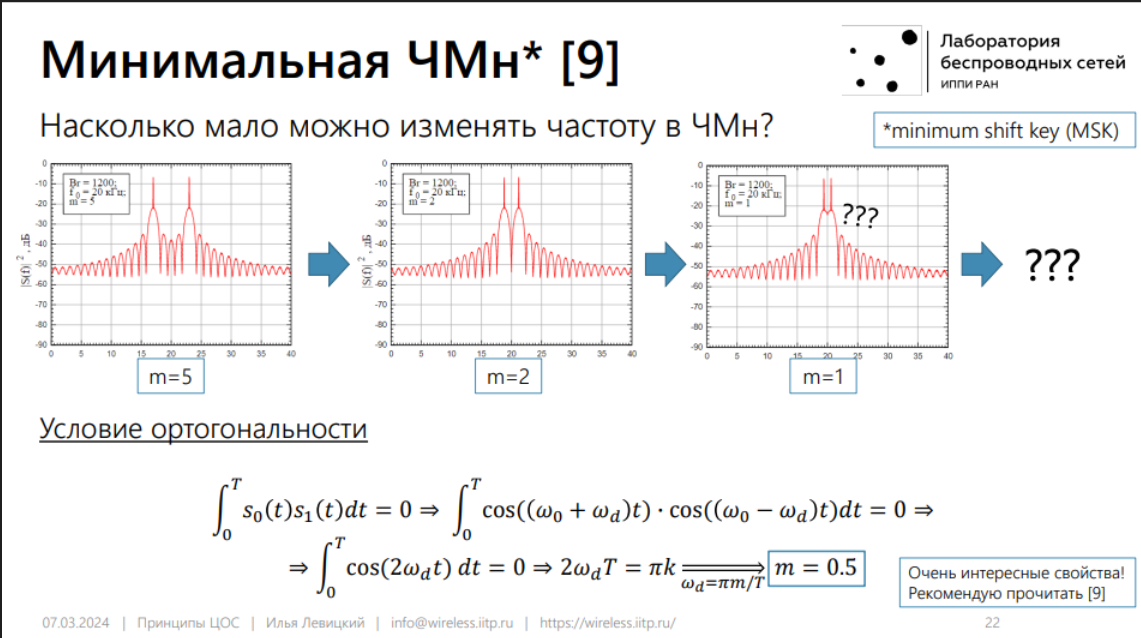

In [4183]:
def modulateCPFSK(modulator, f_c, f_s, f_d, t=[]):
    dt = 1 / f_s
    if len(t) == 0:
        t = np.linspace(0, len(modulator) * dt, len(modulator), endpoint=False)

    return np.cos(2 * np.pi * f_c * t + 2 * np.pi * f_d * np.cumsum(modulator) * dt)

def modulateFSK(modulator, f_c, f_s, f_d, t=[]):
    dt = 1 / f_s
    if len(t) == 0:
        t = np.linspace(0, len(modulator) * dt, len(modulator), endpoint=False)

    return np.cos(2 * np.pi * (f_c + f_d * modulator) * t)

In [4257]:
modulation_func = modulateCPFSK

m = 30
Fd = m / (2 * symbol_duration)  # Гц

print(f"Fd={Fd}")

# Де-нормализация для получения целых индексов уровней как уровней частоты
modulated_signal = premod_filtered_signal * norm_factor

cpfsk_signal = modulation_func(modulated_signal, Fc, Fs, Fd, t_raw_arr)


Fd=661.5


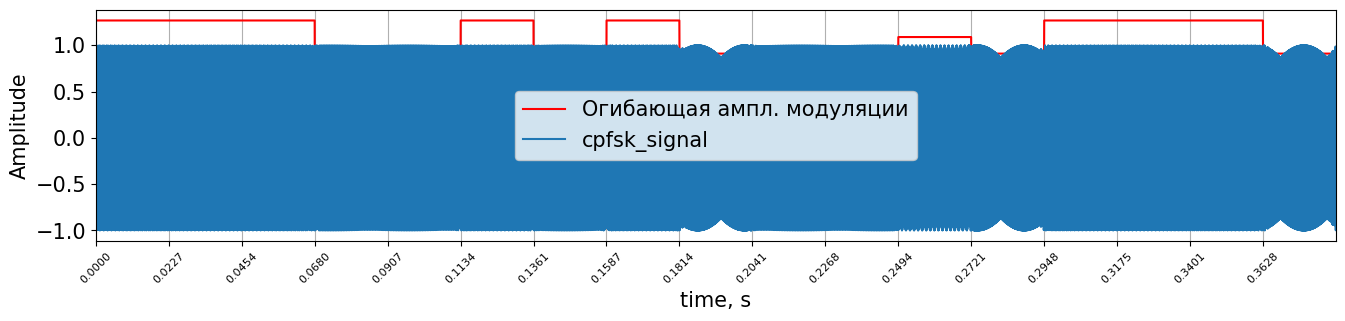

In [4258]:
symbols_to_plot_raw = 10
symbols_to_plot=len(bit_sync_sequence_symbols) + symbols_to_plot_raw

scale_factor = 0.2

plot_symbols(1+scale_factor*appended_normalized_baseband_signal, symbols_to_plot, samples_per_symbol, Fs, label='Огибающая ампл. модуляции', color='red')
plot_symbols(cpfsk_signal, symbols_to_plot, samples_per_symbol, Fs, label='cpfsk_signal')

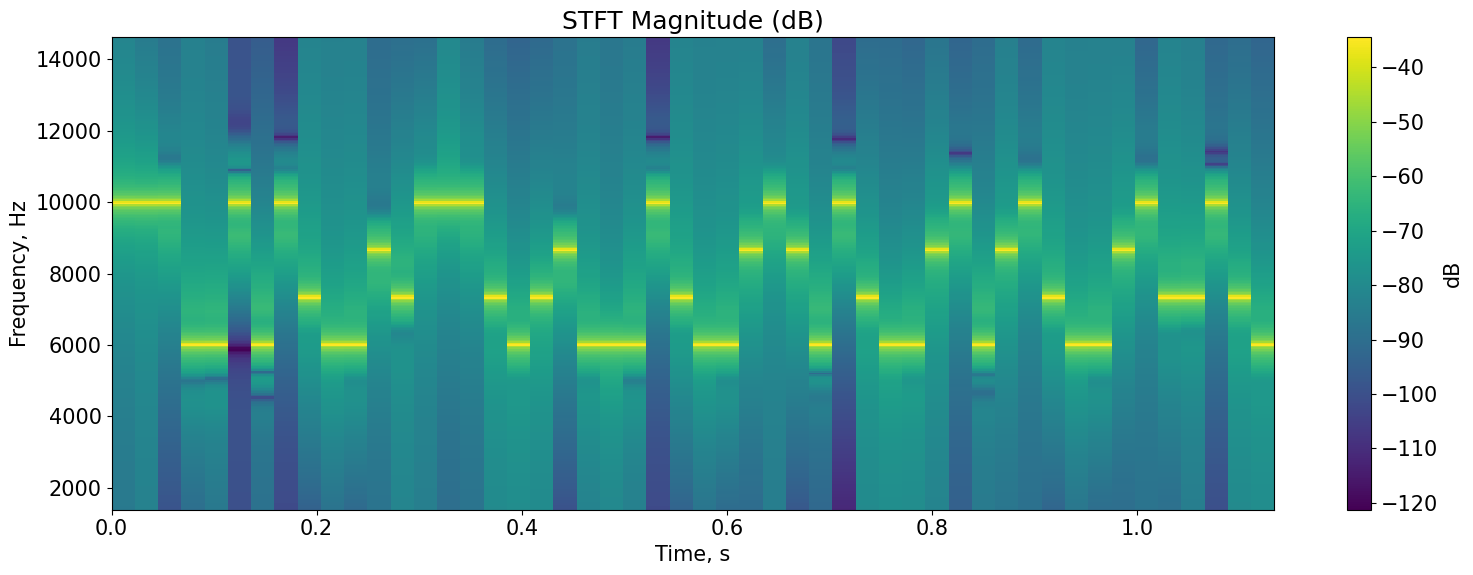

In [4259]:

plotSTFT(cpfsk_signal[0:samples_per_symbol*50], 
         Fs, 
         nperseg=samples_per_symbol, 
         noverlap=0, 
         nfft=samples_per_symbol,   
         F_lim=(Fc-10*Fd, Fc+10*Fd),
         use_log_scale=True)

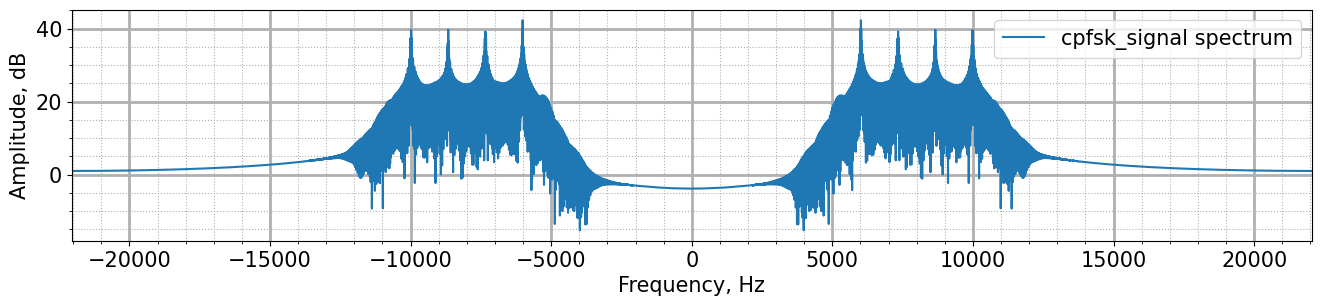

In [4260]:
use_log = True
Fmax = Fs / 2

plotAmplFreqResp(cpfsk_signal, Fs, Fmax, use_log_scale=use_log, label='cpfsk_signal spectrum')

### Добавляем тренировочную последовательность (после модуляции)

In [4261]:
# Длительность сигнала для обучения должна быть кратна длительности символа, чтобы не было проблем с синхронизацией
train_signal_len_symbols = math.ceil(len(train_signal)/samples_per_symbol)
print(f"len(train_signal): {len(train_signal)}")
print(f"train_signal_len_symbols: {train_signal_len_symbols}")
zero_padding_train_len = train_signal_len_symbols * samples_per_symbol - len(train_signal)
print(f"zero_padding_train_len: {zero_padding_train_len}")
assert zero_padding_train_len == 0  # Сделал так, потому что проще работать с кратным числом символов

len(train_signal): 20000
train_signal_len_symbols: 20
zero_padding_train_len: 0


In [4262]:
scale_factor = 1.5
train_signal_padded = np.concatenate((np.zeros(zero_padding_train_len),train_signal)) * scale_factor
train_signal_padded_len_symbols = int(len(train_signal_padded) / samples_per_symbol)

# Добавляем в конец и начало сигнала дополнительные нули, чтобы была пауза
zeroes_padding = np.zeros(samples_per_symbol * 10)
zeroes_padding_len_symbols = int(len(zeroes_padding) / samples_per_symbol)

In [4263]:
train_signal_cpfsk = np.concatenate((zeroes_padding, train_signal_padded, cpfsk_signal, zeroes_padding))
t_final_signal_arr = np.linspace(0, len(train_signal_cpfsk)*dt, len(train_signal_cpfsk), endpoint=False)
print(f"Длительность итогового сигнала: {t_final_signal_arr[-1]} s")

Длительность итогового сигнала: 3.786825396825397 s


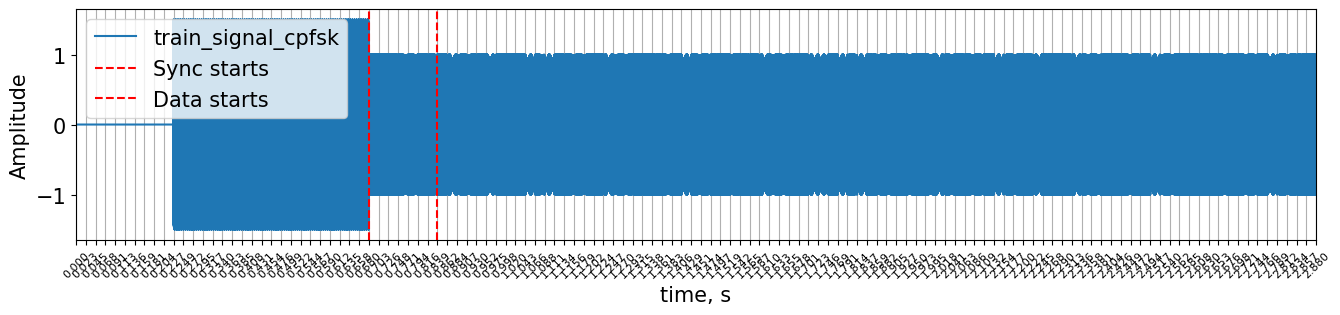

In [4264]:

symbols_to_plot_raw = 100
symbols_to_plot=math.ceil(len(train_signal_padded)/samples_per_symbol) + len(bit_sync_sequence_symbols) + symbols_to_plot_raw
plot_symbols(train_signal_cpfsk, symbols_to_plot, samples_per_symbol, Fs, label='train_signal_cpfsk')
plt.axvline(x=(zeroes_padding_len_symbols*samples_per_symbol + len(train_signal_padded))*dt, color='red', linestyle='--', label='Sync starts')
plt.axvline(x=(len(train_signal_padded)+(len(bit_sync_sequence_symbols)+zeroes_padding_len_symbols)*samples_per_symbol)*dt, color='red', linestyle='--', label='Data starts')
plt.legend(loc='upper left')
plt.show()

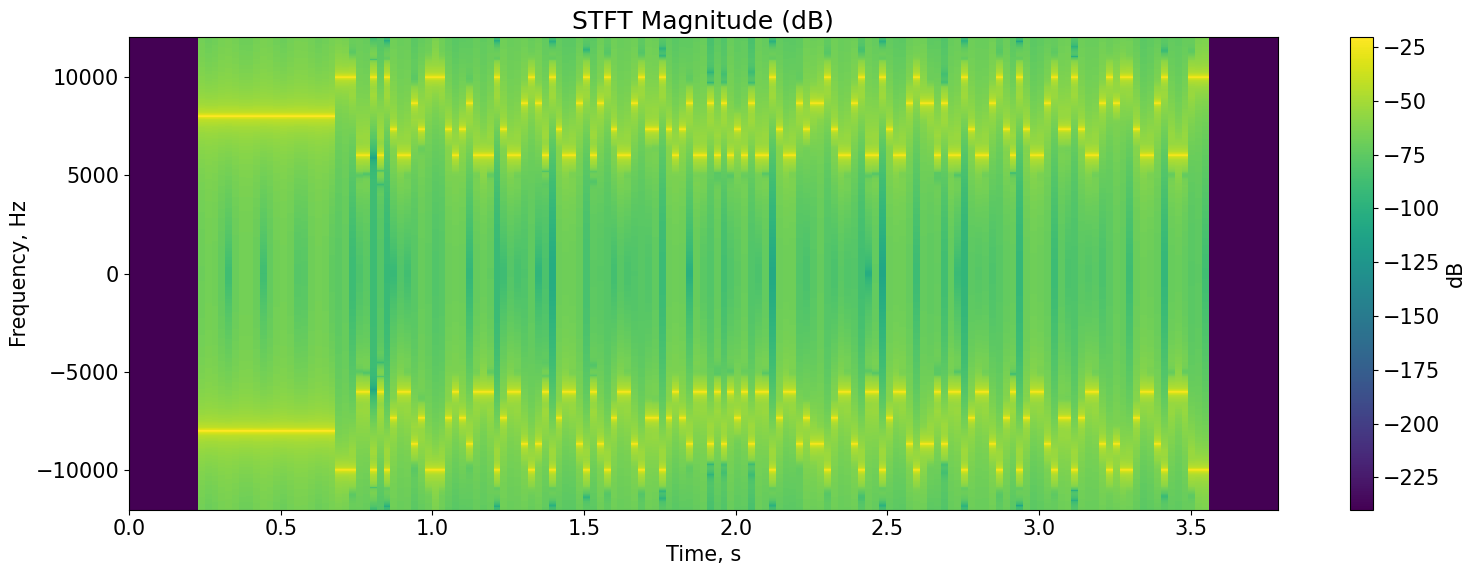

In [4265]:
plotSTFT(train_signal_cpfsk, # [0:symbols_to_plot*samples_per_symbol], 
         Fs, 
         nperseg=samples_per_symbol, 
         noverlap=0, 
         nfft=samples_per_symbol,   
         Fmax=12000,
         use_log_scale=True)

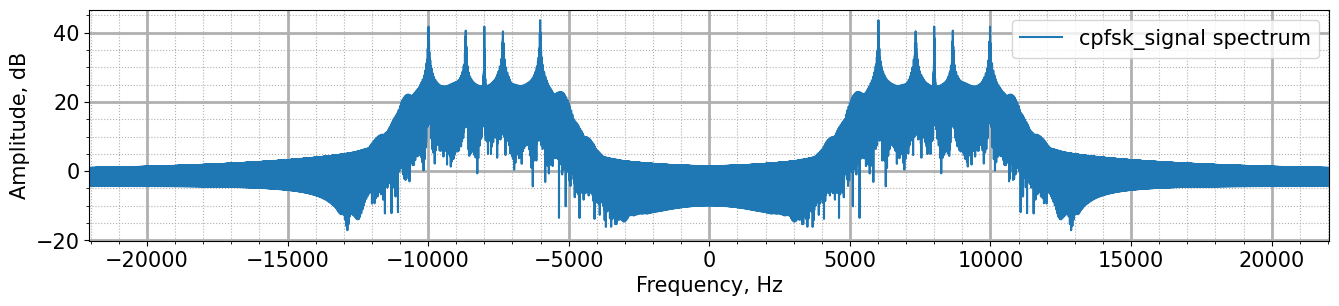

In [4266]:
use_log = True
Fmax = Fs / 2

plotAmplFreqResp(train_signal_cpfsk, Fs, Fmax, use_log_scale=use_log, label='cpfsk_signal spectrum')

## 5. Запись в wav файл

In [4267]:
sf.write('train_signal_cpfsk.wav', train_signal_cpfsk, Fs)

print(f"Длительность записи: {len(train_signal_cpfsk) * dt} s")

Длительность записи: 3.7868480725623583 s


## 7. Записываю звук на диктофон

$$SNR_{dB} = 10 \log_{10} \left( \frac{P_{signal}}{P_{noise}} \right)$$
$$P_{signal} = \frac{1}{N} \sum_{i=1}^{N} |x_i|^2$$
$$SNR_{linear} = 10^{\frac{SNR_{dB}}{10}}$$
$$\sigma = \sqrt{P_{noise}} = \sqrt{\frac{P_{signal}}{SNR_{linear}}}$$

In [4268]:
def get_sigma_from_snr(signal, snr_db):
        sig_power = np.mean(np.abs(signal)**2)
        snr_linear = 10**(snr_db / 10)
        
        return np.sqrt(sig_power / snr_linear)

Извиняюсь, что сделал запись 5 секунд, так просто удобнее записывать

In [4481]:
should_transmit = False

if should_transmit:
    duration = 5 # seconds
    recorded_signal_raw = sd.rec(int(duration * Fs), samplerate=Fs, channels=1)
    sd.wait()
    
    recorded_signal_raw = (recorded_signal_raw / np.max(np.abs(recorded_signal_raw))).T[0]
else:
    make_noise = True

    modulated_signal = train_signal_cpfsk

    snr_db = 15 # dB
    sigma = get_sigma_from_snr(modulated_signal, snr_db)
    display(sigma)
    noise = np.random.normal(loc=0, scale=sigma, size=len(modulated_signal)) if make_noise else np.tile(0, len(modulated_signal))

    recorded_signal_raw = modulated_signal + noise
        
t_recorded_signal_arr = np.linspace(0, len(recorded_signal_raw)*dt, len(recorded_signal_raw), endpoint=False)
print(f"Длительность записанного сигнала: {t_recorded_signal_arr[-1]} s")

np.float64(0.12761251342991725)

Длительность записанного сигнала: 3.786825396825397 s


In [4482]:
sf.write('recorded_signal_raw.wav', recorded_signal_raw, Fs)

In [4483]:
sd.play(recorded_signal_raw)
sd.wait()

Спектр?

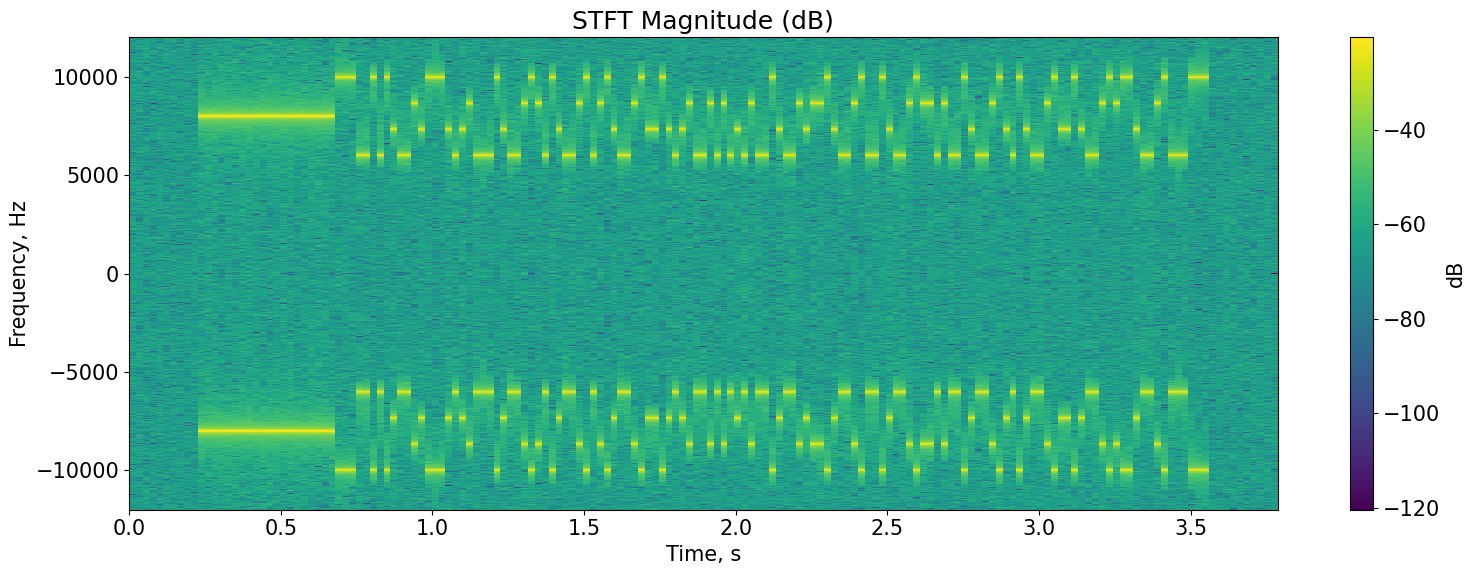

In [4484]:
plotSTFT(recorded_signal_raw,
         Fs, 
         nperseg=samples_per_symbol, 
         noverlap=0, 
         nfft=samples_per_symbol,   
         Fmax=12000,
         use_log_scale=True)

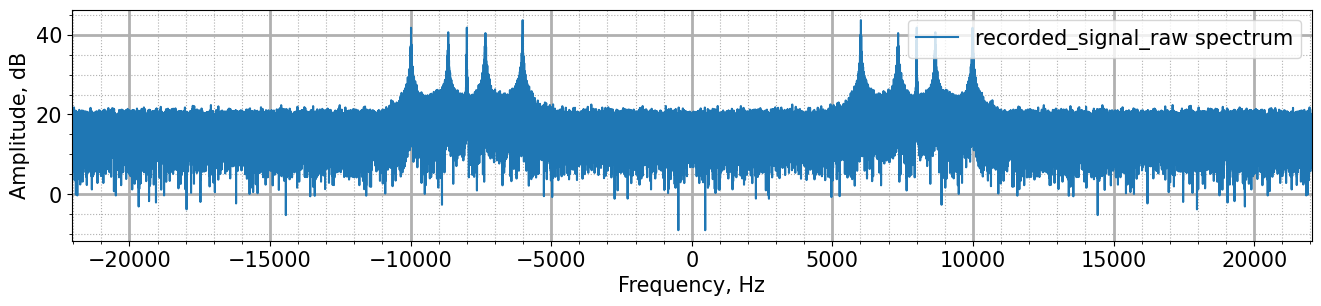

In [4485]:
use_log = True
Fmax = Fs / 2

plotAmplFreqResp(recorded_signal_raw, Fs, Fmax, use_log_scale=use_log, label='recorded_signal_raw spectrum')
plt.legend(loc='upper right')
plt.show()

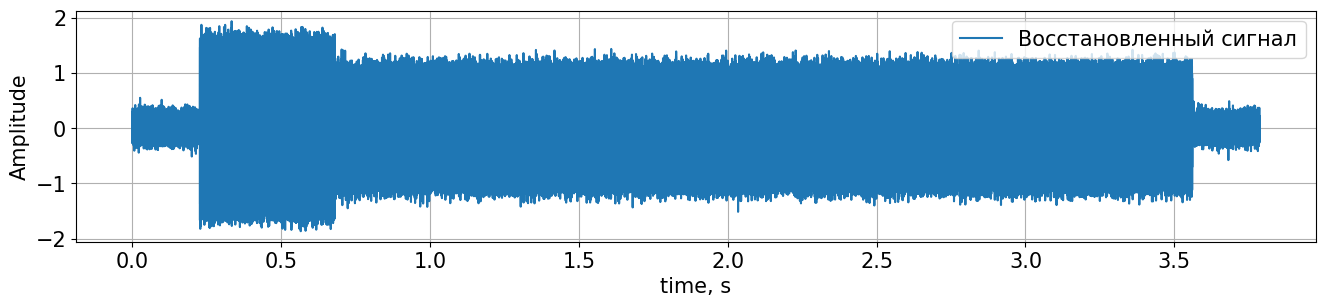

In [4486]:
plotSignalTime(recorded_signal_raw, Fs, label='Восстановленный сигнал')

Попробуем вырезать низкочастотный гул микрофона из спектра по центру (он лишь добавляет шумы и мешает искать основной сигнал - выяснено опытным путем)

In [4487]:
sos_hp = sg.iirfilter(N=4, Wn=2000, btype='highpass', fs=Fs, output='sos')
recorded_signal = sg.sosfiltfilt(sos_hp, recorded_signal_raw)

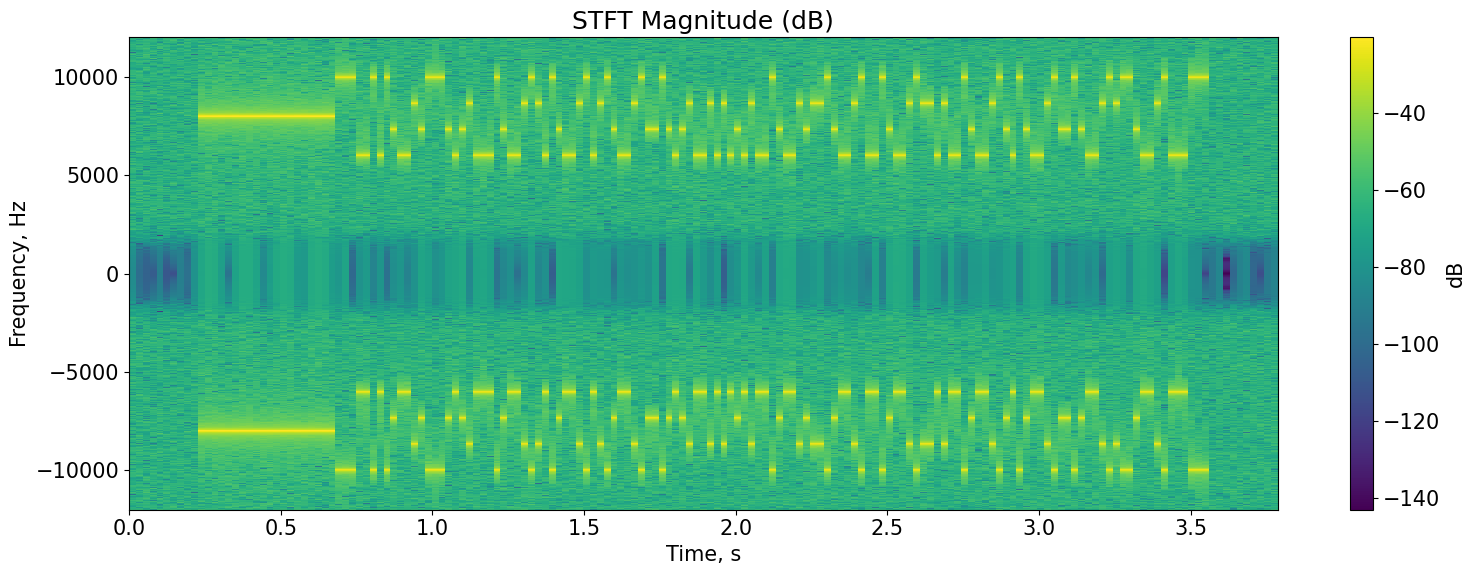

In [4488]:
plotSTFT(recorded_signal, 
         Fs, 
         nperseg=samples_per_symbol, 
         noverlap=0, 
         nfft=samples_per_symbol,   
         Fmax=12000,
         use_log_scale=True)

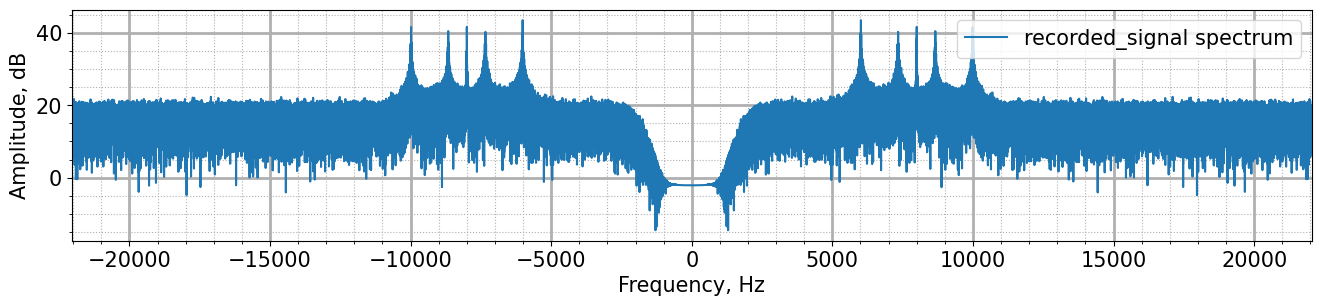

In [4489]:
use_log = True
Fmax = Fs / 2

plotAmplFreqResp(recorded_signal, Fs, Fmax, use_log_scale=use_log, label='recorded_signal spectrum')
plt.legend(loc='upper right')
plt.show()

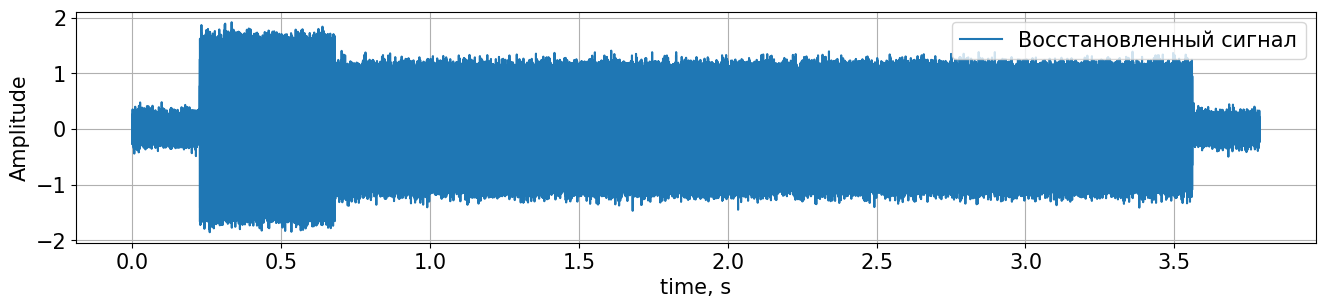

In [4490]:
plotSignalTime(recorded_signal, Fs, label='Восстановленный сигнал')

Вот теперь хорошо, попробуем задетектировать энергию

In [4494]:
envelope = np.abs(sg.hilbert(recorded_signal)) 
train_start_idx = np.argmax(envelope > 0.5* np.max(envelope))  # Сканирование по мощности в канале
sync_start_idx = train_start_idx + train_signal_padded_len_symbols * samples_per_symbol
data_start_idx = sync_start_idx + len(bit_sync_sequence_symbols) * samples_per_symbol
data_end_idx = data_start_idx + data_size_symbols * samples_per_symbol

print(f"train_start_idx: {train_start_idx}")
print(f"sync_start_idx: {sync_start_idx}")
print(f"data_start_idx: {data_start_idx}")
print(f"data_end_idx: {data_end_idx}")

train_start_idx: 10000
sync_start_idx: 30000
data_start_idx: 37000
data_end_idx: 157000


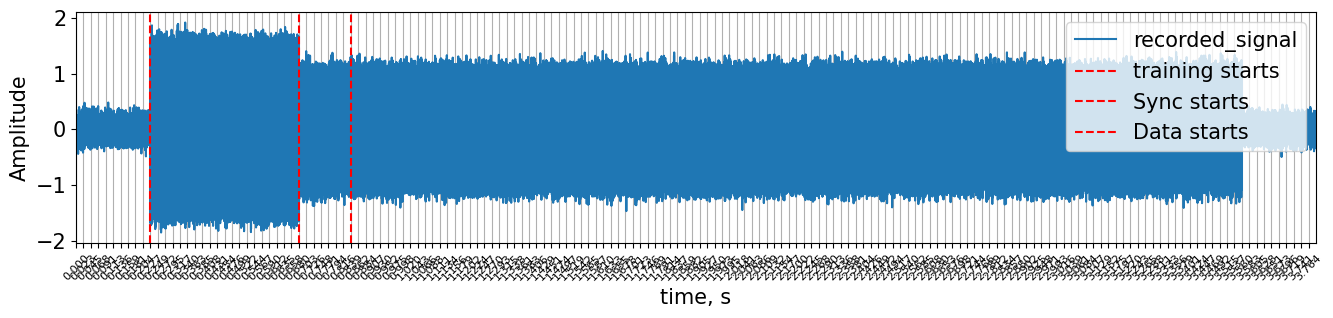

In [4495]:
symbols_to_plot = len(recorded_signal) // samples_per_symbol

plot_symbols(recorded_signal, symbols_to_plot, samples_per_symbol, Fs, label='recorded_signal')

plt.axvline(x=train_start_idx*dt, color='red', linestyle='--', label='training starts')
plt.axvline(x=sync_start_idx*dt, color='red', linestyle='--', label='Sync starts')
plt.axvline(x=data_start_idx*dt, color='red', linestyle='--', label='Data starts')
plt.legend(loc='upper right')
plt.show()

Отлично

## 8. Ищем реальную частоту после передачи

Важно! На графике видим ~ треугольник - потому что размерность дпф не такая большая. Если поставить ~1_000_000, то спектр будет гладкий (ДВПФ)

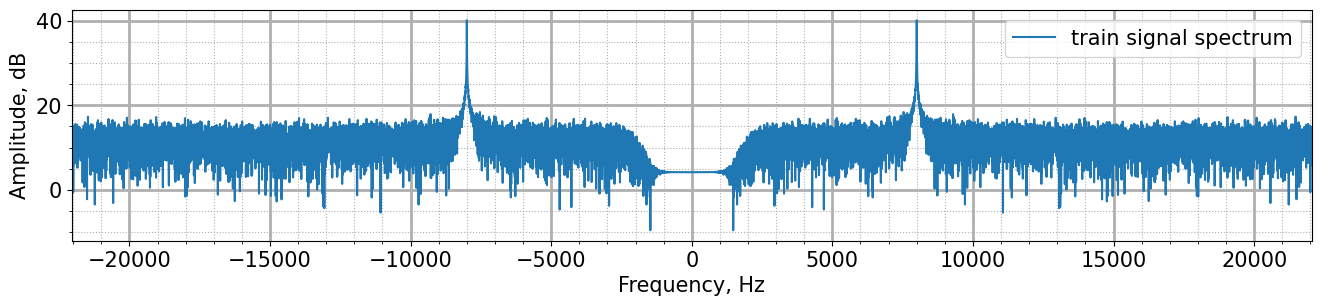

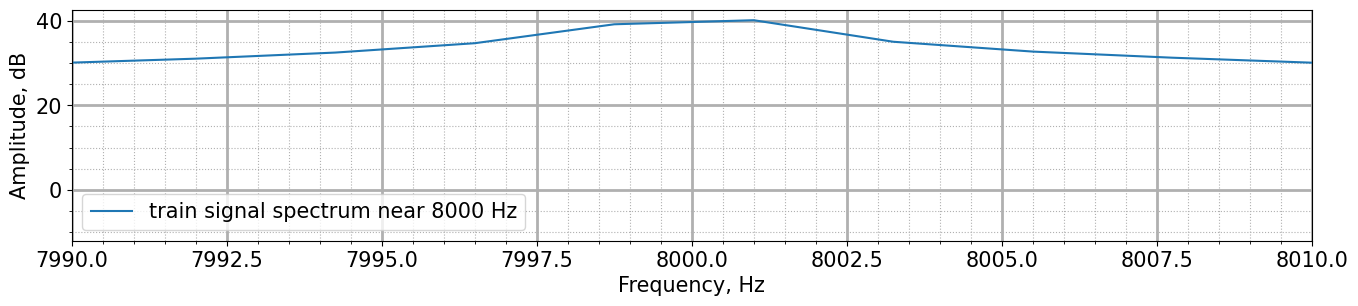

In [4496]:
DFT_size = None # 1_000_000

use_log = True
Fmax = Fs / 2

offset = (sync_start_idx - train_start_idx) // 100

plotAmplFreqResp(recorded_signal[train_start_idx + offset:sync_start_idx - offset], 
                 Fs, use_log_scale=use_log, label='train signal spectrum', DFT_size=DFT_size)
plt.show()
plotAmplFreqResp(recorded_signal[train_start_idx + offset:sync_start_idx - offset], 
                 Fs, use_log_scale=use_log, label='train signal spectrum near 8000 Hz', f_lim=(7990, 8010), DFT_size=DFT_size)

Проверяем условие, что действительно можно найти Fs точно (по разрешению ДПФ)

In [4497]:
len(recorded_signal[train_start_idx + offset:sync_start_idx - offset])

19600

In [4498]:
Fc / (Fs/len(recorded_signal[train_start_idx + offset:sync_start_idx - offset]))

3555.5555555555557

Ищем пик

In [4499]:
fft_signal = np.fft.fft(recorded_signal[train_start_idx + offset:sync_start_idx - offset], n=10_000_000)
fft_signal = np.fft.fftshift(fft_signal) 
frequencies = np.fft.fftfreq(len(fft_signal), d=1/Fs)
frequencies = np.fft.fftshift(frequencies)

expected_fc = 8000
mask = (frequencies > expected_fc - 1000) & (frequencies < expected_fc + 1000)
Fc_founded = frequencies[mask][np.argmax(np.abs(fft_signal)[mask])]

# Fc_founded = Fc
dt_founded = 1 / Fc_founded

print(f"Fc_founded: {Fc_founded} Hz")
print(f"dt_founded: {dt_founded} s")

Fc_founded: 8000.00019 Hz
dt_founded: 0.00012499999703125008 s


Будем надеяться, что это действительно правильная частота

## 9. Демодуляция сигнала

Поскольку мы не знаем, когда точно заканчивается тренировочная последовательность (если мы просто отрежем сигнал более высокой амплитуды, то мы можем неточно найти стык между ней и дальнейшим сигналом), будем демодулировать прямо с ней. Синхросигнал для того и нужен, чтобы потом правильно отрезать кусок массива

In [4500]:
bandwith_half_to_filter = 3000

In [4501]:
Fc_founded - bandwith_half_to_filter - 500

np.float64(4500.00019)

### Фильтруем от шума и домножаем на несущую

In [4502]:
bpf = sg.iirdesign(wp=[Fc_founded - bandwith_half_to_filter      , Fc_founded + bandwith_half_to_filter      ], 
                   ws=[Fc_founded - bandwith_half_to_filter - 500, Fc_founded + bandwith_half_to_filter + 500], 
                   gpass=0.1, gstop=80, fs=Fs, output='sos')

# Фильтруем зашумленный сигнал ДО демодуляции
recorded_signal_clean = sg.sosfiltfilt(bpf, recorded_signal)
recorded_signal_not_filtered = recorded_signal_clean * np.exp(-1j*2 * np.pi * Fc_founded * t_recorded_signal_arr)

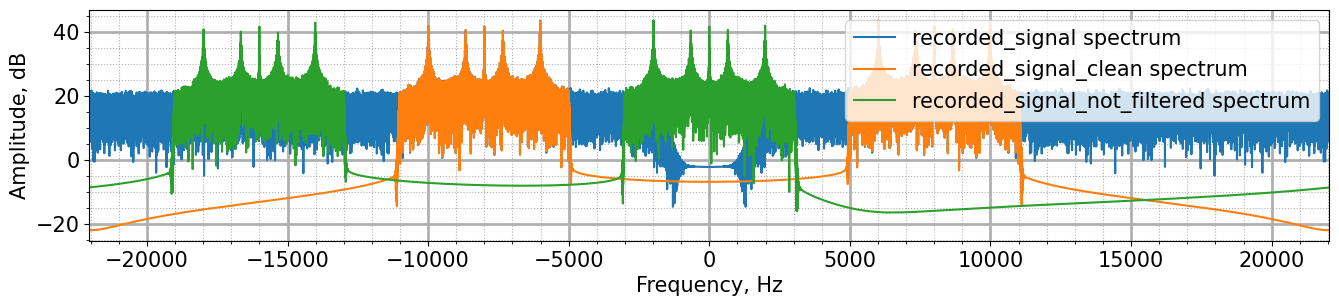

In [4503]:
use_log = True
Fmax = Fs / 2 / 1

plotAmplFreqResp(recorded_signal, Fs, Fmax, use_log_scale=use_log, label='recorded_signal spectrum')
plotAmplFreqResp(recorded_signal_clean, Fs, Fmax, use_log_scale=use_log, label='recorded_signal_clean spectrum')
plotAmplFreqResp(recorded_signal_not_filtered, Fs, Fmax, use_log_scale=use_log, label='recorded_signal_not_filtered spectrum')

# plt.ylim((-10, 70))

### Фильтруем

In [4504]:
cutoff_freq = bandwith_half_to_filter

sos_bessel = sg.iirfilter(N=4, Wn=cutoff_freq, btype='low', fs=Fs, output='sos')
recorded_signal_filtered = sg.sosfiltfilt(sos_bessel, recorded_signal_not_filtered)

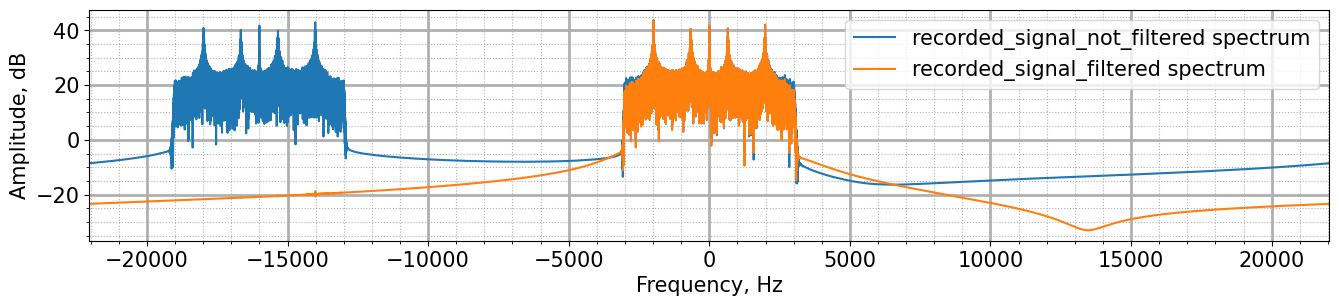

In [4505]:
use_log = True
Fmax = Fs / 2 / 1

plotAmplFreqResp(recorded_signal_not_filtered, Fs, Fmax, use_log_scale=use_log, label='recorded_signal_not_filtered spectrum')
plotAmplFreqResp(recorded_signal_filtered, Fs, Fmax, use_log_scale=use_log, label='recorded_signal_filtered spectrum')

# plt.ylim((-20, 60))

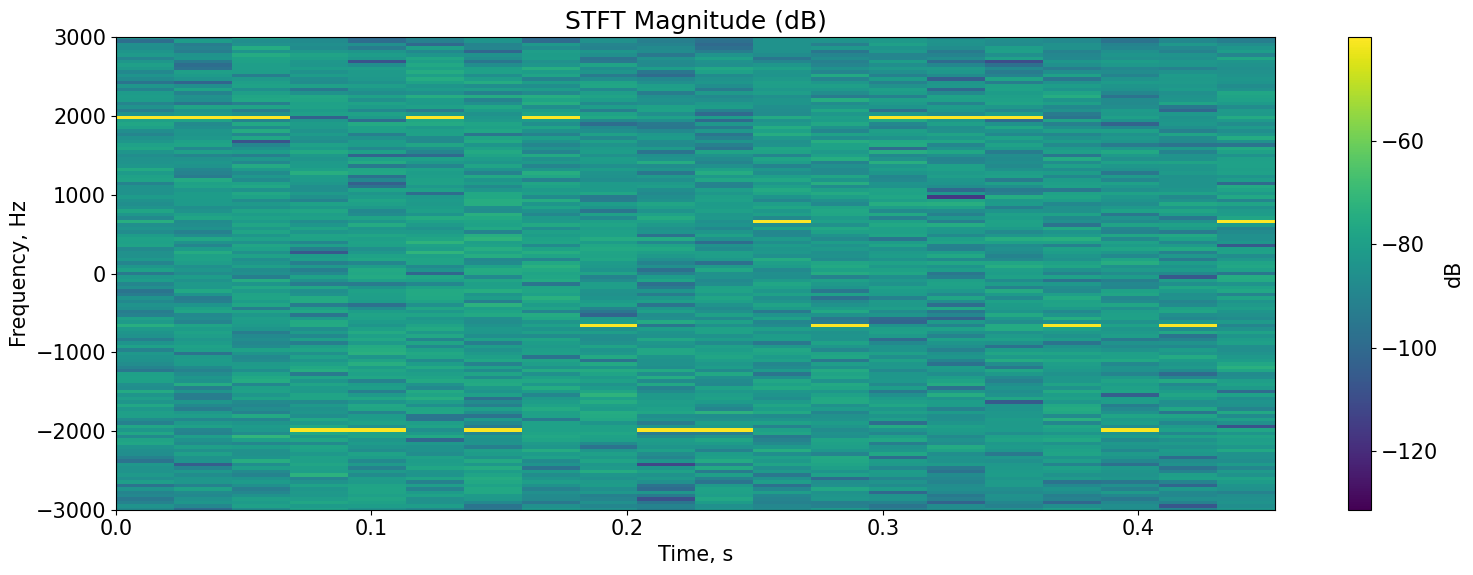

In [4506]:
symbols_to_plot = 20

plotSTFT(recorded_signal_filtered[sync_start_idx:sync_start_idx + symbols_to_plot*samples_per_symbol], 
         Fs, 
         nperseg=samples_per_symbol, 
         noverlap=0, 
         nfft=samples_per_symbol, 
         Fmax=3000,
         use_log_scale=True)

Ну с таким-то спектром тут грех не демодулировать... (спойлер: в некоторых попытках не получалось, ха...)

### Окончательно демодулируем сигнал

restored_modulated_signal_filtered = $\mathrm{exp}
( 2 \pi F_d \cdot \int s_m(t) dt )$

In [4507]:
restored_cumsum_of_s_m = np.unwrap(np.angle(recorded_signal_filtered)) / (2 * np.pi * Fd)
baseband_discrete_levels_restored = np.diff(restored_cumsum_of_s_m) / dt

# Чтобы восстановить длину, так как diff уменьшает длину на 1
baseband_discrete_levels_restored = np.append(baseband_discrete_levels_restored, baseband_discrete_levels_restored[-1])  

# Убираем лишние проблемы до CPFSK и после данных
baseband_discrete_levels_restored[:sync_start_idx] = 0
baseband_discrete_levels_restored[data_end_idx:] = 0

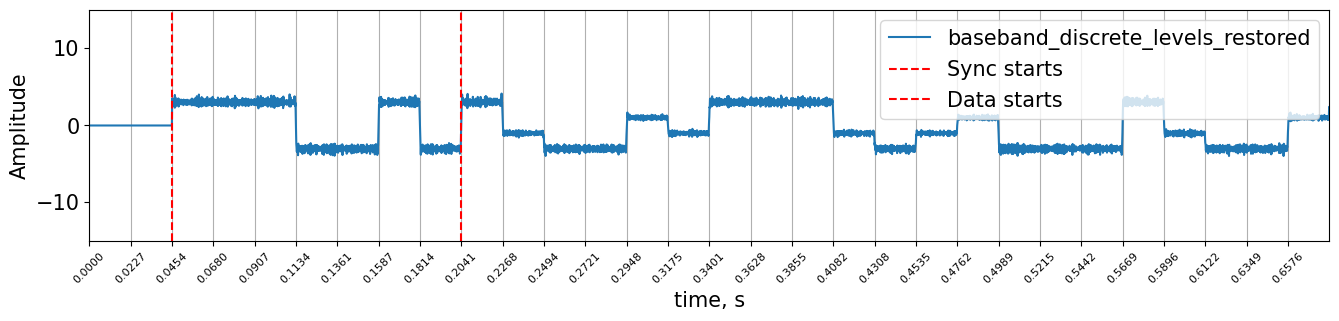

In [4508]:
symbols_to_plot = 30 # data_size_symbols + 20

plot_start_idx = sync_start_idx - 2*samples_per_symbol

plot_symbols(baseband_discrete_levels_restored[plot_start_idx:], symbols_to_plot, samples_per_symbol, Fs, label='baseband_discrete_levels_restored')

plt.axvline(x=-plot_start_idx*dt + sync_start_idx*dt, color='red', linestyle='--', label='Sync starts')
plt.axvline(x=-plot_start_idx*dt + data_start_idx*dt, color='red', linestyle='--', label='Data starts')
plt.legend(loc='upper right')
plt.ylim((-15, 15))
plt.show()

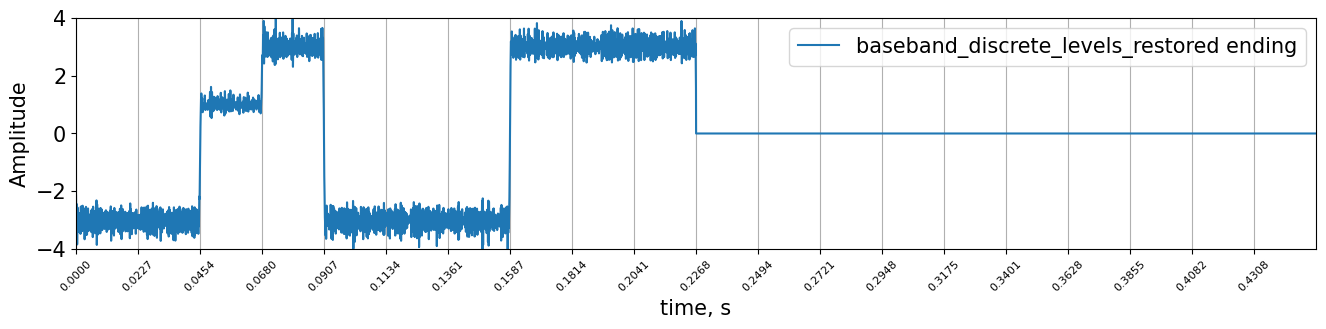

In [4509]:
symbols_to_plot = 20

plot_start_idx = data_end_idx - 10*samples_per_symbol

plot_symbols(baseband_discrete_levels_restored[plot_start_idx:], symbols_to_plot, samples_per_symbol, Fs, label='baseband_discrete_levels_restored ending', y_lim=(-4, 4))


Выглядит грустно. Но посмотрим на спектр. Видно, что после дифференцирования добавилось крайне много высокочастотного шума!

(-10.0, 50.0)

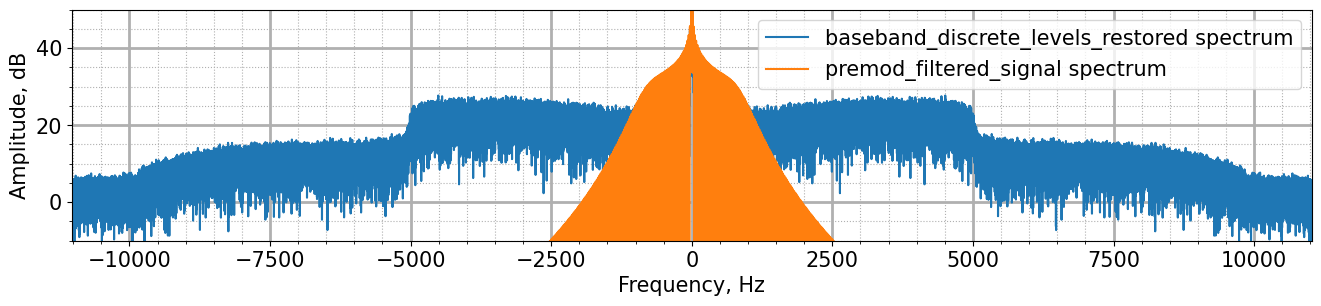

In [4510]:
use_log = True
Fmax = Fs / 2 / 2

plotAmplFreqResp(baseband_discrete_levels_restored, Fs, Fmax, use_log_scale=use_log, label='baseband_discrete_levels_restored spectrum')
plotAmplFreqResp(premod_filtered_signal * 3, Fs, Fmax, use_log_scale=use_log, label='premod_filtered_signal spectrum')

plt.ylim(-10, 50)

А какая у нас базовая частота изменения символов?

In [4511]:
1 / symbol_duration

44.1

Очень маленькая! Значит стоит поставить низкочастотный фильтр

In [4512]:
cutoff_freq = 1 / symbol_duration * 10

sos_bessel = sg.iirfilter(N=4, Wn=cutoff_freq, btype='low', fs=Fs, output='sos')
baseband_discrete_levels_restored_filtered = sg.sosfiltfilt(sos_bessel, baseband_discrete_levels_restored)

(-10.0, 50.0)

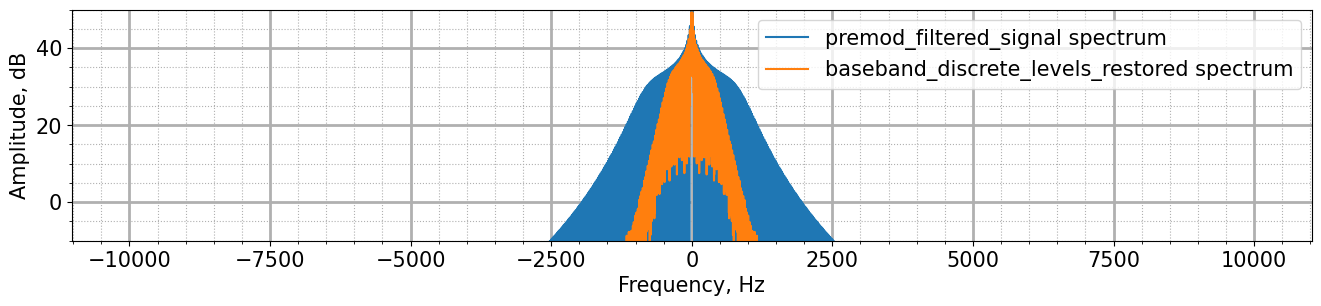

In [4513]:
use_log = True
Fmax = Fs / 2 / 2

plotAmplFreqResp(premod_filtered_signal * 3, Fs, Fmax, use_log_scale=use_log, label='premod_filtered_signal spectrum')
plotAmplFreqResp(baseband_discrete_levels_restored_filtered, Fs, Fmax, use_log_scale=use_log, label='baseband_discrete_levels_restored spectrum')


plt.ylim(-10, 50)

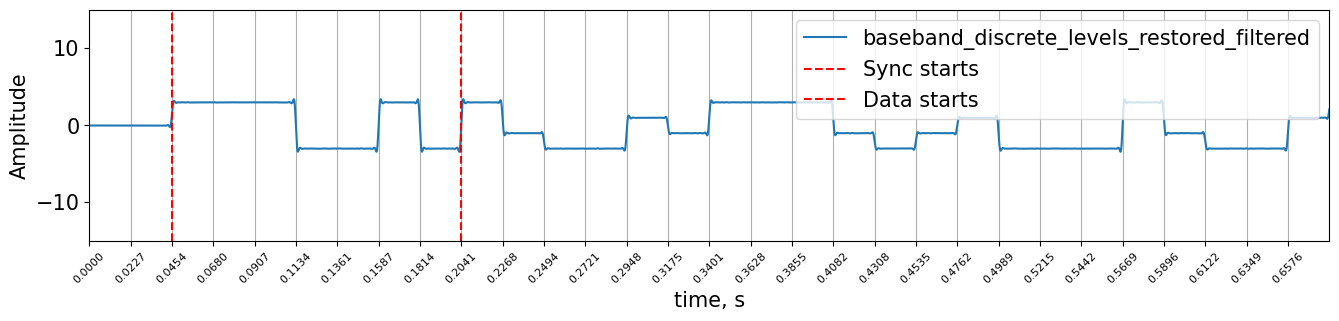

In [4514]:
symbols_to_plot = 30 # data_size_symbols + 20

plot_start_idx = sync_start_idx - 2*samples_per_symbol

plot_symbols(baseband_discrete_levels_restored_filtered[plot_start_idx:], symbols_to_plot, samples_per_symbol, Fs, label='baseband_discrete_levels_restored_filtered')

plt.axvline(x=-plot_start_idx*dt + sync_start_idx*dt, color='red', linestyle='--', label='Sync starts')
plt.axvline(x=-plot_start_idx*dt + data_start_idx*dt, color='red', linestyle='--', label='Data starts')
plt.legend(loc='upper right')
plt.ylim((-15, 15))
plt.show()

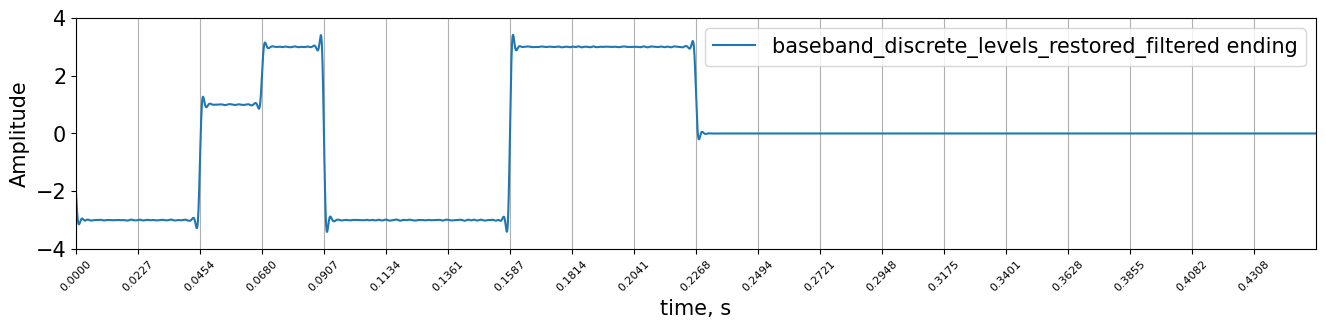

In [4515]:
symbols_to_plot = 20

plot_start_idx = data_end_idx - 10*samples_per_symbol

plot_symbols(baseband_discrete_levels_restored_filtered[plot_start_idx:], symbols_to_plot, samples_per_symbol, Fs, label='baseband_discrete_levels_restored_filtered ending', y_lim=(-4, 4))


Выглядит крайне хорошо!!!

## 10. Применяем синхропоследовательность

Periodic autocorrelation


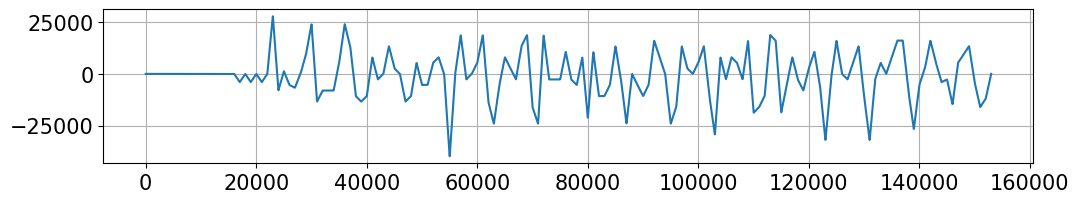

Linear autocorrelation


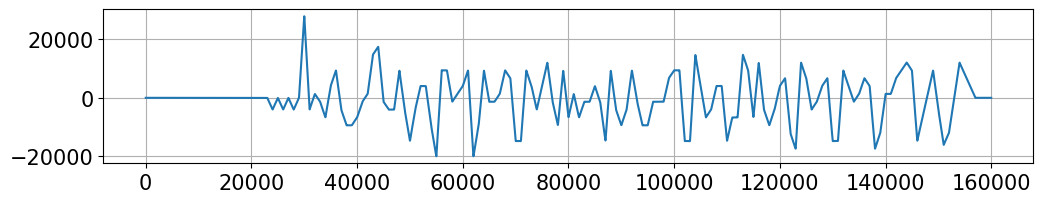

In [4516]:
# Periodic autocorrelation #
print("Periodic autocorrelation")
plt.figure(figsize=(12, 2))
plt.plot(periodic_corr_np(baseband_discrete_levels_restored_filtered, normalized_bit_sync_sequence_wide))
plt.grid(visible=True, which='major', axis='both')
plt.show()

# Linear autocorrelation #
linear_corr = np.correlate(baseband_discrete_levels_restored_filtered, normalized_bit_sync_sequence_wide, mode='valid')

print("Linear autocorrelation")
plt.figure(figsize=(12, 2))
plt.plot(linear_corr)
plt.grid(visible=True, which='major', axis='both')

Используем линейную автокорреляцию (не периодическую), она выглядит получше

In [4517]:
# Берем по модулю, чтобы поймать в случае чего инверсию фазы
abs_corr = np.abs(linear_corr)
peaks = sg.find_peaks(abs_corr, height=0.5*np.max(abs_corr))
peak_index_same = peaks[0][0]  # Это точный индекс начала синхропоследовательности
payload_index = peak_index_same + len(normalized_bit_sync_sequence_wide)

# Если сигнал инвертировался в канале, исправляем это:
if linear_corr[peak_index_same] < 0:
    baseband_discrete_levels_restored_filtered *= -1

print(f"Пик: {peak_index_same}, значение в пике: {linear_corr[peak_index_same]}")
print(f"Длина синхросигнала: {len(normalized_bit_sync_sequence_wide)}")
print(f"Найденный индекс начала данных: {payload_index}")
print(f"data_start_idx: {data_start_idx}")
print(f"Действительный индекс начала данных: {zeroes_padding_len_symbols*samples_per_symbol + train_signal_padded_len_symbols * samples_per_symbol + len(bit_sync_sequence_symbols) * samples_per_symbol} (значение указано только для передачи НЕ по воздуху)")

restored_data_symbols = baseband_discrete_levels_restored_filtered[payload_index:payload_index + data_size_symbols*samples_per_symbol]

Пик: 29998, значение в пике: 27852.420258006343
Длина синхросигнала: 7000
Найденный индекс начала данных: 36998
data_start_idx: 37000
Действительный индекс начала данных: 37000 (значение указано только для передачи НЕ по воздуху)


(-6.0, 6.0)

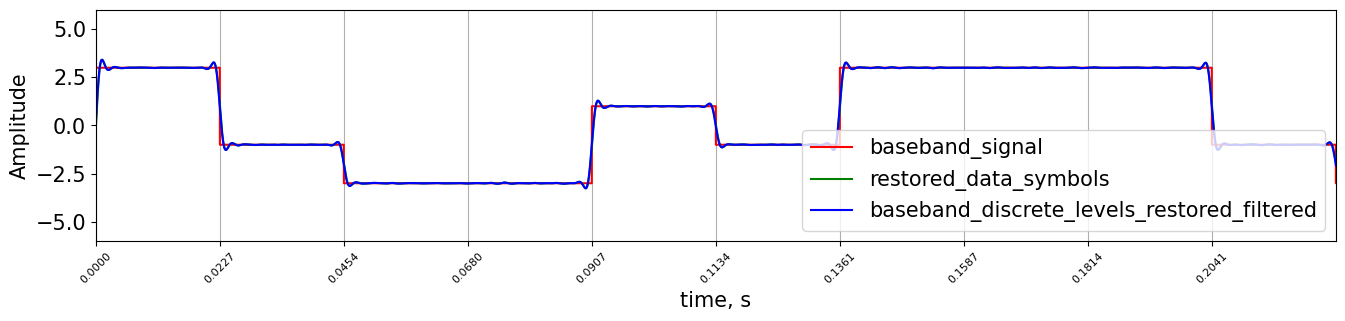

In [4518]:
symbols_to_plot = 10

plot_symbols(baseband_signal,
                symbols_to_plot, samples_per_symbol, Fs, label='baseband_signal', color='red')

plot_symbols(restored_data_symbols, 
             symbols_to_plot, samples_per_symbol, Fs, label='restored_data_symbols', color='green')

plot_symbols(baseband_discrete_levels_restored_filtered[data_start_idx:], 
             symbols_to_plot, samples_per_symbol, Fs, label='baseband_discrete_levels_restored_filtered', color='blue')

plt.ylim((-6, 6))

Видна небольшая сдвижка по индексу, но это не страшно (видна если длительность символа поменьше сделать, а так не особо видна)

## 11. Hard decision decoding

In [4519]:
def symbols_to_bits(symbols, bits_per_symbol):
    
    # '02b' означает: заполнить нулями до 2 знаков, двоичная система (b)
    bit_string = "".join(format(s, f'0{bits_per_symbol}b') for s in symbols)
    
    return np.array([int(b) for b in bit_string])

def calculate_BER(original_bits, decoded_bits):
    errors = np.sum(original_bits != decoded_bits)
    return errors / len(original_bits), errors


In [4520]:
def detect_by_avaraging(data_symbols_noised, samples_per_symbol):
    data_symbols_noised_reshaped = data_symbols_noised.reshape(-1, samples_per_symbol)
    data_symbols_avaraged = np.mean(data_symbols_noised_reshaped, axis=1)
    return data_symbols_avaraged.flatten()

def detect_by_averaging_central(data_symbols_noised, samples_per_symbol, central_ratio = 0.4):
    
    reshaped = data_symbols_noised.reshape(-1, samples_per_symbol)
    
    # Вычисляем количество семплов для обрезки
    num_central_samples = int(samples_per_symbol * central_ratio)
    # Если 70% — это 0, берем хотя бы 1 семпл, чтобы не упасть
    num_central_samples = max(1, num_central_samples)
    
    start_idx = (samples_per_symbol - num_central_samples) // 2
    end_idx = start_idx + num_central_samples
    
    data_symbols_averaged = np.mean(reshaped[:, start_idx:end_idx], axis=1)
    return data_symbols_averaged.flatten()

def detect_by_center_sampling(data_symbols_noised, samples_per_symbol):
    return data_symbols_noised[samples_per_symbol//2 :: samples_per_symbol]

In [4521]:
detected_signal = detect_by_averaging_central(restored_data_symbols, samples_per_symbol, central_ratio=0.8)


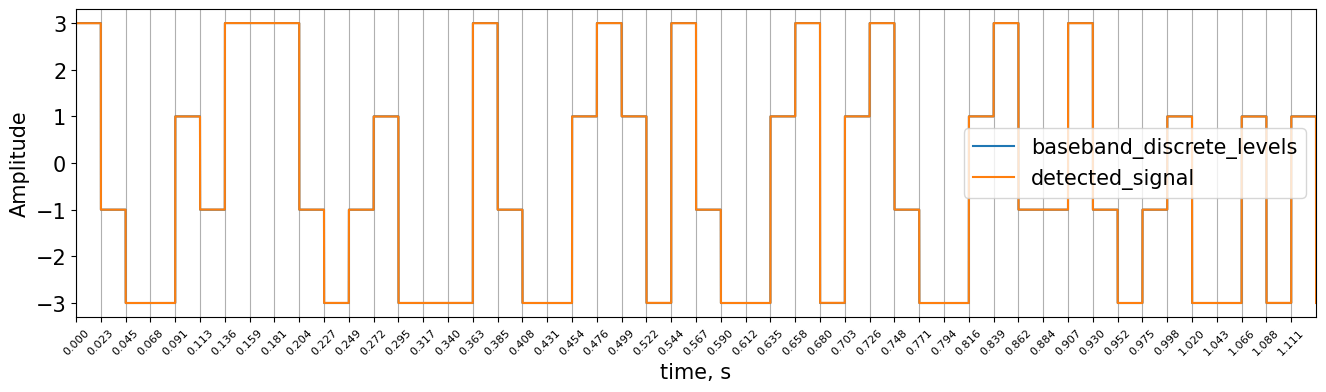

In [4522]:
symbols_to_plot = 50

plot_symbols(baseband_signal, 
             symbols_to_plot, samples_per_symbol, Fs, label='baseband_discrete_levels')

plot_symbols(make_wide(detected_signal, samples_per_symbol, scale_multiplier=1), 
             symbols_to_plot, samples_per_symbol, Fs, label='detected_signal', figsize=(16, 4))

Количество ошибочных символов: 0
Количество ошибочных бит: 0
BER (Bit Error Rate): 0.0000


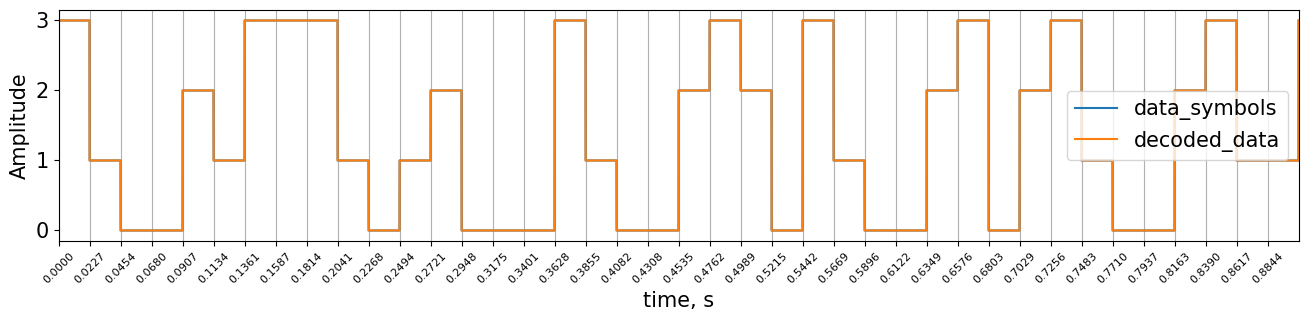

In [4523]:
restored_signal = detected_signal # * norm_factor
restored_symbols = (restored_signal + alphabet_size - 1) / scale_multiplier

decoded_data = np.round(restored_symbols).astype(int)
decoded_data = np.clip(decoded_data, 0, alphabet_size - 1)

original_bits = symbols_to_bits(data_symbols, bits_per_symbol)
decoded_bits = symbols_to_bits(decoded_data, bits_per_symbol)

# BER
ber, errors = calculate_BER(original_bits, decoded_bits)

symbol_errors = np.sum(data_symbols != decoded_data)

print(f"Количество ошибочных символов: {symbol_errors}")
print(f"Количество ошибочных бит: {errors}")
print(f"BER (Bit Error Rate): {ber:.4f}")

symbols_to_plot = 40

plot_symbols(make_wide(data_symbols, samples_per_symbol, scale_multiplier=1),    symbols_to_plot, samples_per_symbol, Fs, label='data_symbols')
plot_symbols(make_wide(decoded_data, samples_per_symbol, scale_multiplier=1), symbols_to_plot, samples_per_symbol, Fs, label='decoded_data')

## 12. Конвертируем массив бит обратно в строку

In [4524]:
bits_reshaped = decoded_bits.reshape(-1, 8)
powers = 2 ** np.arange(8)[::-1]  # Степени двойки
bytes_decoded = bits_reshaped.dot(powers)

decoded_string = bytes_decoded.astype(np.uint8).tobytes().decode('utf-8', errors='replace')  # Декодируем в строку, заменяя некорректные символы

print(decoded_string)

errors_str = sum(1 for i in range(len(message_str)) if decoded_string[i] != message_str[i])

print(f"Вероятность успешной передачи одного символа: {(1-ber)**16 * 100:.2f}%")
print(f"Количество ошибок в строке: {errors_str}/{len(message_str)}")

Привет! Как дела?
Вероятность успешной передачи одного символа: 100.00%
Количество ошибок в строке: 0/17


Победа!!!

TRANSMITTER

1. Write a string to bit array converter.
2. Prepend a known bit synchronization sequence.
- For further frequency synchronization, you may add simple training field, if required*.
3. Convert bit array to baseband signal.
- Sampling frequency is 44100 Hz.
- Use any symbol duration you feel suitable.
- Plot a portion of your baseband signal. 
- Show where the synchronization sequence starts and ends*. Do the same for training field.*
- Make sure your signal is no longer than 3 sec! 
4. Modulate it with the FSK (e.g. MSK) modulation. Use any carrier frequency you feel suitable.
- Plot a portion of your singal
- Plot spectral density of that portion 
5. Write your audio to the wav file.
6. Use filters of your choice at any point required.
- Using FFT of signal is prohibited! Apply genuine, non-ideal filter. 

RECEIVER

7. Play your audio from the phone and record the audio it with your laptop. 
- This simulated wireless transmission
- Make sure the audio you play is properly recorded from start to finish! Test recoding in Sound recording and playing example.
- Plot a potion of received singal
- Plot spectral density of that portion 
8. Fix carrier frequency shift.*
- Suppose you know the approximate carrier frequency. 
- Find the actual carrier frequency of signal and use it afterwards. Use training field of you signal if required.
- Multiplying approximate carrier frequency by actual (and filtering) may leave slow phase drift. Find it and compensate.
- Show the value of estimated frequency offset.
9. Demodulate your singal.
- Use demodulation techniques from previous labs.
- Suppose you know the precise symbol duration and approximate carrier frequency.
- Plot a portion of the resulting baseband signal
10. Using ACF, find the synchronization sequence and derive the start of your signal with payload.
- Plot the ACF you get. Make you graph clear!
- Warning! The phase of the signal may be impaired! Use synchronization sequence to fix phase error.
- Assuming you know the duration of your message, cut the signal to leave payload only.
- For extra points, you may include control data in the signal to tell the actual length*
11. Make hard-decision decoding for the received baseband signal. 
12. Convert bit array back to string and print it.
13. Use filters of your choice at any point required.
- Using FFT of signal is prohibited. Apply genuine, non-ideal filter.

Подсказки

Для упрощения, возможно, удобно будет обрезать начало при записи.

При приеме проверьте, что сигнал не обрезался. Сравните сигналы переданный и принятый по времени и по частоте. 

Вероятно, фаза и частота принятого сигнала будут смещены! Компенсируйте если нужно!

Начало сигнала ищите при помощи корреляции.

Можно в начале сигнала указать длительность сообщения, чтобы не "знать заранее" сколько бит вы шлете, а находить это при приеме.

Чтобы проверить фазу сигнала во времени - можно домножать на комл. эксп. и взять angle. Исходя из этого возможно увидеть смещение несущей частоты (фаза линейно растет/падает).